# IEEE-CIS Fraud Detection - EDA

This notebook performs exploratory data analysis on the IEEE-CIS Fraud Detection dataset downloaded from Kaggle. The labelled dataset has two files, `train_transaction.csv`
and `train_identity.csv`, which are merged using `TransactionID`.

The purpose of this notebook is to examine the dataset structure, class imbalance, missing values, transaction characteristics, categorical feature distributions,
temporal patterns and relationships between numerical features and fraud.

Data preprocessing, feature preparation and machine-learning modelling are performed separately in the preprocessing and modelling notebook.



** Transaction Table **

TransactionDT: timedelta from a given reference datetime (not an actual timestamp)

TransactionAmt: transaction payment amount in USD

ProductCD: product code, the product for each transaction

card1 - card6: payment card information, such as card type, card category, issue bank, country, etc.

addr: address

dist: distance

P_emaildomain and R_emaildomain : purchaser and recipient email domain

C1-C14: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked.

D1-D15: timedelta, such as days between previous transaction, etc.

M1-M9: match, such as names on card and address, etc.

Vxxx: Vesta engineered rich features, including ranking, counting, and other entity relations.

Categorical Features: ProductCD card1 - card6 addr1, addr2 P_emaildomain R_emaildomain M1 - M9


** Identity Table **

Variables in this table are identity information – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta’s fraud protection system and digital security partners. (The field names are masked and a detailed feature dictionary is not provided for privacy protection.)

Categorical Features: DeviceType DeviceInfo id_12 - id_38

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Load data

### 2.1 Load "train_transaction.csv" and "train_identity.csv" datasets; and check their shapes

In [2]:
# === DATA PATH ===
BASE_DIR = Path("/Users/lata.bharati/Desktop/FraudShield")
DATA_FOLDER = BASE_DIR / "IEEE-CIS Fraud Detection Raw Datasets"

def load_fraud_data(data_folder=DATA_FOLDER):
    data_folder = Path(data_folder)
    print("Data folder:", data_folder)
    print("Folder exists:", data_folder.exists())

    train_transaction = pd.read_csv(data_folder / "train_transaction.csv")
    train_identity = pd.read_csv(data_folder / "train_identity.csv")

    print("Transaction data shape:", train_transaction.shape)
    print("Identity data shape:", train_identity.shape)
    return train_transaction, train_identity

In [3]:
train_transaction, train_identity = load_fraud_data()

Data folder: /Users/lata.bharati/Desktop/FraudShield/IEEE-CIS Fraud Detection Raw Datasets
Folder exists: True
Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)


### 2.2 Display columns with datatype and non-null count for both train_transaction and train_identity

In [4]:
train_transaction.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 394 columns):
 #    Column          Non-Null Count   Dtype  
---   ------          --------------   -----  
 0    TransactionID   590540 non-null  int64  
 1    isFraud         590540 non-null  int64  
 2    TransactionDT   590540 non-null  int64  
 3    TransactionAmt  590540 non-null  float64
 4    ProductCD       590540 non-null  str    
 5    card1           590540 non-null  int64  
 6    card2           581607 non-null  float64
 7    card3           588975 non-null  float64
 8    card4           588963 non-null  str    
 9    card5           586281 non-null  float64
 10   card6           588969 non-null  str    
 11   addr1           524834 non-null  float64
 12   addr2           524834 non-null  float64
 13   dist1           238269 non-null  float64
 14   dist2           37627 non-null   float64
 15   P_emaildomain   496084 non-null  str    
 16   R_emaildomain   137291 non-null  str    
 17   

In [5]:
pd.set_option('display.max_columns',394)
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [6]:
train_identity.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


In [7]:
pd.set_option('display.max_columns', 41)
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


# 3. Merge transaction and identity data 

### 3.1 Merge transaction and identity data and add a column to indicate if identity data is available

In [8]:
# Create a copy of the original dataframes to avoid modifying them directly
transaction_df = train_transaction.copy()
identity_df = train_identity.copy()

# Add column to show identity data is available
identity_df["has_identity"] = 1

# Merge transaction and identity data using TransactionID
df = transaction_df.merge(identity_df, on="TransactionID", how="left")

# If identity data is not available replace NaN with 0
df["has_identity"] = df["has_identity"].fillna(0).astype("int8")

print("Transaction data shape:", transaction_df.shape)
print("Identity data shape:", identity_df.shape)
print("Merged data shape:", df.shape)

print("Without identity data:", (df["has_identity"] == 0).sum())
print("With identity data:", (df["has_identity"] == 1).sum())

Transaction data shape: (590540, 394)
Identity data shape: (144233, 42)
Merged data shape: (590540, 435)
Without identity data: 446307
With identity data: 144233


A binary feature, "has_identity", was created to show whether matching identity-table record was available for each transaction.
A value of 1 indicates that a matching identity record was present, while 0 indicates that no matching record was available.

In [9]:
# Display all columns in the dataframe
pd.set_option('display.max_columns',435)
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.

### 3.2 Check for duplicate values in the merged dataset

In [10]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate TransactionIDs:", df["TransactionID"].duplicated().sum())
print("Unique TransactionIDs:", df["TransactionID"].nunique())

Duplicate rows: 0
Duplicate TransactionIDs: 0
Unique TransactionIDs: 590540


There were no duplicate values in the datset, hence each transaction was unique.

### 3.3 Identify the categorical and numerical fetures (as per information available on Kaggle)

In [11]:
# Categorical features based on the dataset description(as per information available on Kaggle)
categorical_features = (["ProductCD"] + [f"card{i}" for i in range(1, 7)] + ["addr1", "addr2", "P_emaildomain", "R_emaildomain"] + [f"M{i}" for i in range(1, 10)]
                        + ["DeviceType", "DeviceInfo"] + [f"id_{i:02d}" for i in range(12, 39)])

categorical_features = [ col for col in categorical_features if col in df.columns]

# Numerical features
numerical_features = [
    col for col in df.columns
    if col not in categorical_features
    and col not in ["TransactionID", "isFraud"]
]

print("Categorical features:", len(categorical_features))
print(categorical_features)

print("\nNumerical features:", len(numerical_features))
print(numerical_features)

Categorical features: 49
['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

Numerical features: 384
['TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V

In [12]:
# Create a function to determine the feature type based on the column name
def get_feature_type(column):

    if column == "TransactionID":
        return "Identifier"

    elif column == "isFraud":
        return "Target"

    elif column in categorical_features:
        return "Categorical"

    else:
        return "Numerical"

feature_type_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values,
    "Feature Type": [
        get_feature_type(col)
        for col in df.columns
    ]
})

display(feature_type_summary)

,Feature,Data Type,Unique Values,Feature Type
0,TransactionID,int64,590540,Identifier
1,isFraud,int64,2,Target
2,TransactionDT,int64,573349,Numerical
3,TransactionAmt,float64,20902,Numerical
4,ProductCD,str,5,Categorical
...,...,...,...,...
430,id_37,str,2,Categorical
431,id_38,str,2,Categorical
432,DeviceType,str,2,Categorical
433,DeviceInfo,str,1786,Categorical


Categorical features: 49
['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

Numerical features: 384
['TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V241', 'V242', 'V243', 'V244', 'V245', 'V246', 'V247', 'V248', 'V249', 'V250', 'V251', 'V252', 'V253', 'V254', 'V255', 'V256', 'V257', 'V258', 'V259', 'V260', 'V261', 'V262', 'V263', 'V264', 'V265', 'V266', 'V267', 'V268', 'V269', 'V270', 'V271', 'V272', 'V273', 'V274', 'V275', 'V276', 'V277', 'V278', 'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285', 'V286', 'V287', 'V288', 'V289', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V296', 'V297', 'V298', 'V299', 'V300', 'V301', 'V302', 'V303', 'V304', 'V305', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V313', 'V314', 'V315', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321', 'V322', 'V323', 'V324', 'V325', 'V326', 'V327', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'has_identity']

### 3.4 Fraud Rate based on the availability of identity data

,Transaction_Count,Fraud_Rate
has_identity,,
0,446307,2.093850
1,144233,7.847025


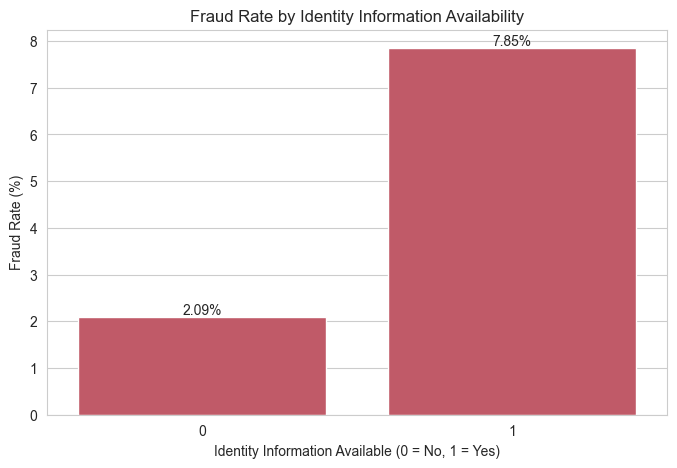

In [13]:
identity_summary = (df.groupby("has_identity")["isFraud"].agg(Transaction_Count="count", Fraud_Rate="mean"))

identity_summary["Fraud_Rate"] *= 100
display(identity_summary)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=identity_summary.reset_index(), x="has_identity", y="Fraud_Rate", color="#D1495B")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2.0, p.get_height()), ha="center", va="center", xytext=(0, 5), textcoords="offset points")
plt.xlabel("Identity Information Available (0 = No, 1 = Yes)")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Identity Information Availability")
plt.show()

Transactions with identity information had higher observed fraud rate (7.85%) than transactions without identity information (2.09%). This suggested that identity-record was related with fraud status. The identity table was only a subset of transaction table. So the higher rate might refelct that the identity data was collected only for certain type of transactions.

### 3.4.1 Identity Record Availabilty By Product Type

In [14]:
product_identity = (df.groupby("ProductCD")["has_identity"].agg(Transaction_Count="count", Identity_Count="sum", Identity_Rate="mean"))
product_identity["Identity_Rate"] *= 100
display(product_identity.sort_values("Identity_Rate",ascending=False))

,Transaction_Count,Identity_Count,Identity_Rate
ProductCD,,,
H,33024,32908,99.648740
S,11628,11585,99.630203
R,37699,37548,99.599459
C,68519,62192,90.766065
W,439670,0,0.000000


Identity record was completely missing for product type W, whereas other categories H,S, and R had approx 99.5% identity data available and C had 90.7% identity data. 

### 3.4.2 Fraud rate by product type and identity availability

In [15]:
product_identity_fraud = (df.groupby(["ProductCD", "has_identity"])["isFraud"].agg(Transaction_Count="count", Fraud_Rate="mean").reset_index())
product_identity_fraud["Fraud_Rate"] *= 100
display(product_identity_fraud)

,ProductCD,has_identity,Transaction_Count,Fraud_Rate
0,C,0,6327,5.816343
1,C,1,62192,12.284538
2,H,0,116,2.586207
3,H,1,32908,4.773915
4,R,0,151,1.986755
5,R,1,37548,3.789816
6,S,0,43,4.651163
7,S,1,11585,5.904186
8,W,0,439670,2.039939


In [16]:
product_fraud = (df.groupby("ProductCD")["isFraud"].agg(Transaction_Count="count", Fraud_Rate="mean"))
product_fraud["Fraud_Rate"] *= 100
display(product_fraud)

,Transaction_Count,Fraud_Rate
ProductCD,,
C,68519,11.687269
H,33024,4.766231
R,37699,3.782594
S,11628,5.899553
W,439670,2.039939


The fraud rate by product type was found minimum from W with 2.03% whereas other types had fraud percentage from 3-11%.

### 3.4.3 Association between Product Type and Identity Availability

In [17]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["ProductCD"], df["has_identity"])
chi2 = chi2_contingency(table)[0]

n = table.sum().sum()
r, k = table.shape

cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))
print("Cramér's V:", cramers_v)

Cramér's V: 0.971845478549293


# 4. Missing Values

### 4.1 Overall missingness

In [18]:
# Create a table of all columns containing missing values
missing_summary = pd.DataFrame({"Missing Count": df.isnull().sum(),"Missing Percentage": (df.isnull().mean() * 100).round(4)})

# Keeping columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values(by="Missing Percentage", ascending=False)

# Show every row
with pd.option_context("display.max_rows", None):
    display(missing_summary)

print("Total columns with missing values:", len(missing_summary))

,Missing Count,Missing Percentage
id_24,585793,99.1962
id_25,585408,99.1310
id_07,585385,99.1271
id_08,585385,99.1271
id_21,585381,99.1264
id_26,585377,99.1257
id_27,585371,99.1247
id_23,585371,99.1247
id_22,585371,99.1247
dist2,552913,93.6284


Total columns with missing values: 414


#### 4.1.1 Top 20 features with highest missing values

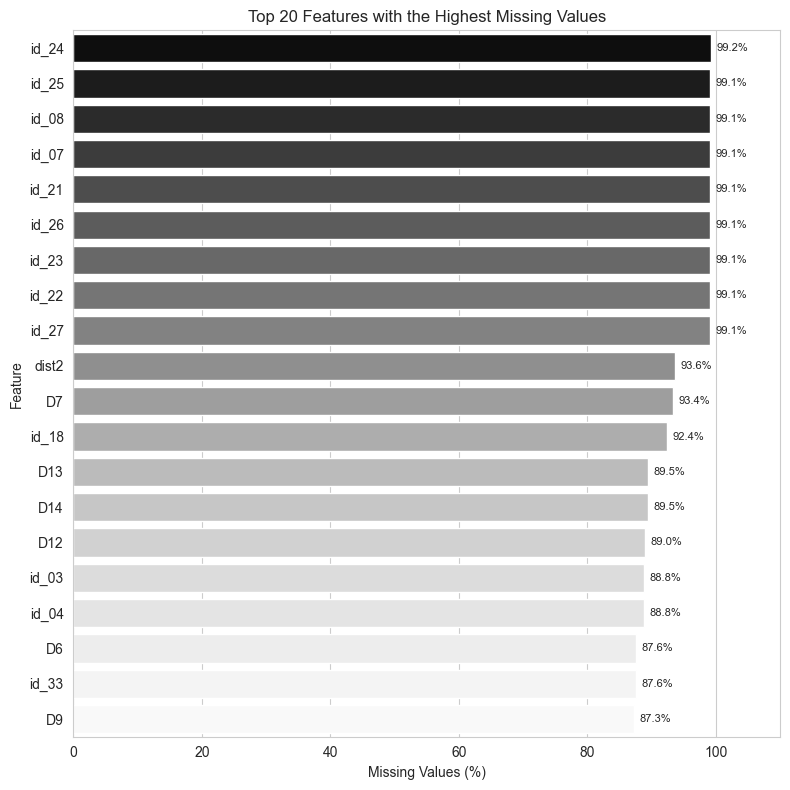

In [19]:
# Calculate missing value percentage
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

# Select top 20 features with highest missing values
top_missing = missing_percentage.head(20)

palette = sns.color_palette("Greys", n_colors=len(top_missing))[::-1]
plt.figure(figsize=(8, 8))
ax = sns.barplot(x=top_missing.values, y=top_missing.index, hue=top_missing.index, palette=palette, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=8)
plt.title("Top 20 Features with the Highest Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.xlim(0, 110)
plt.tight_layout()
plt.show()

#### 4.1.2 Missing value percentage for fraudulent transactions

In [20]:
# Calculate missing value percentage for fraudulent transactions
fraud_missing_percentage = (df[df["isFraud"] == 1].isnull().mean().mul(100).sort_values(ascending=False))
print(fraud_missing_percentage)

id_24           98.054494
id_25           97.981900
id_26           97.943183
id_23           97.938344
id_21           97.938344
                  ...    
C10              0.000000
C11              0.000000
C12              0.000000
C13              0.000000
has_identity     0.000000
Length: 435, dtype: float64


#### 4.1.3 Missing value by class (fraudulent vs legitimate transactions)

In [21]:
# Calculate missing value by class (fraudulent vs legitimate transactions)
missing_by_class = pd.DataFrame({
    "Legitimate Missing %":
        df[df["isFraud"] == 0].isna().mean() * 100,
    "Fraud Missing %":
        df[df["isFraud"] == 1].isna().mean() * 100
})

missing_by_class["Difference"] = (missing_by_class["Fraud Missing %"] - missing_by_class["Legitimate Missing %"])

display(missing_by_class.sort_values("Difference", key=abs, ascending=False).head(20))

,Legitimate Missing %,Fraud Missing %,Difference
R_emaildomain,77.878735,45.666167,-32.212569
id_02,77.249477,45.690364,-31.559112
id_35,77.229648,45.690364,-31.539283
id_38,77.229648,45.690364,-31.539283
id_37,77.229648,45.690364,-31.539283
id_15,77.229648,45.690364,-31.539283
id_36,77.229648,45.690364,-31.539283
id_28,77.230174,45.709723,-31.520452
id_29,77.230174,45.709723,-31.520452
id_11,77.230174,45.709723,-31.520452


Many variables have lower missingness in fraudulent transactions than legitimate transactions. This pattern is mostly seen in identity-related features, V(Vesta Engineered rich features).

#### 4.1.4 Top 20 features with highest missing values in fraud transactions

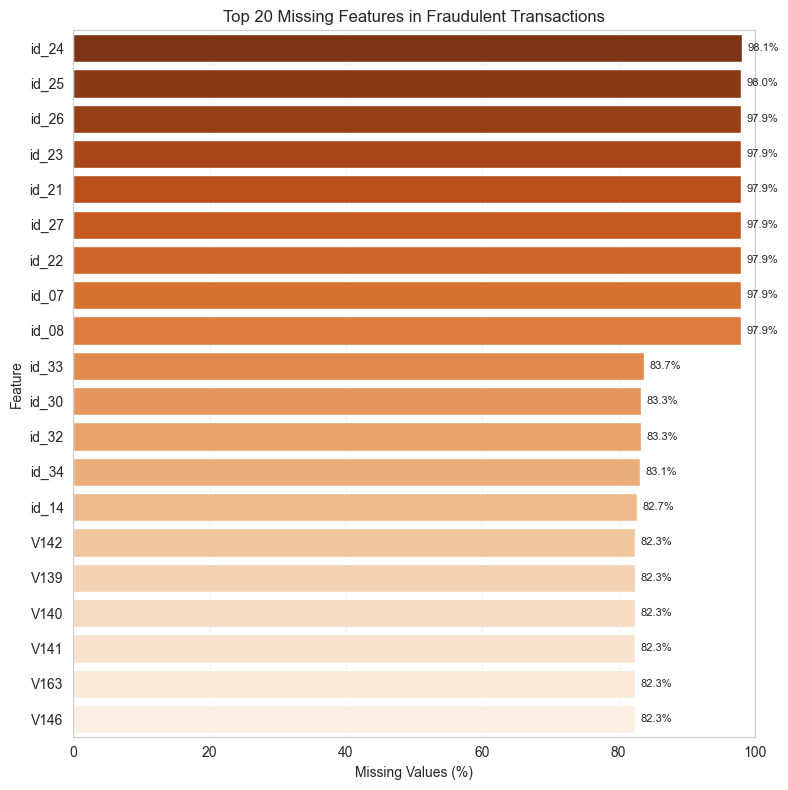

In [22]:
# Top 20 features with highest missing values in fraud transactions
top_fraud_missing = fraud_missing_percentage.head(20)
palette = sns.color_palette("Oranges", n_colors=len(top_fraud_missing))[::-1]

plt.figure(figsize=(8, 8))
ax = sns.barplot(x=top_fraud_missing.values, y=top_fraud_missing.index, palette=palette)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=8)
plt.title("Top 20 Missing Features in Fraudulent Transactions")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

It's clear that for fraululent transactions also id-related and V-features were missing.

#### 4.1.5 Missingness Within Available Identity Records

In [23]:
# Identity columns, excluding merge indicator and ID
identity_cols = [
    col for col in identity_df.columns
    if col not in ["TransactionID", "has_identity"]
]

identity_present = df[df["has_identity"] == 1]

identity_missingness = (identity_present[identity_cols].isna().mean().mul(100).sort_values(ascending=False))
display(identity_missingness.head(20))

id_24         96.708798
id_25         96.441868
id_07         96.425922
id_08         96.425922
id_21         96.423149
id_26         96.420375
id_22         96.416215
id_27         96.416215
id_23         96.416215
id_18         68.722137
id_04         54.016071
id_03         54.016071
id_33         49.187079
id_09         48.052110
id_10         48.052110
id_30         46.222432
id_32         46.207872
id_34         46.056034
id_14         44.503685
DeviceInfo    17.726179
dtype: float64

The transactions for which had matching identity record also had several missing identity features.

In [24]:
transaction_cols = [
    col for col in transaction_df.columns
    if col not in ["TransactionID", "isFraud"]
]

missing_by_identity = (df.groupby("has_identity")[transaction_cols].apply(lambda x: x.isna().mean() * 100).T)
missing_by_identity.columns = ["No Identity (%)","Has Identity (%)"]

missing_by_identity["Difference"] = (missing_by_identity["Has Identity (%)"] - missing_by_identity["No Identity (%)"]).abs()

display(missing_by_identity.sort_values("Difference", ascending=False).head(100))


,No Identity (%),Has Identity (%),Difference
V250,99.930541,2.168020,97.762521
V272,99.930541,2.168020,97.762521
V251,99.930541,2.168020,97.762521
V239,99.930541,2.168020,97.762521
V238,99.930541,2.168020,97.762521
...,...,...,...
V246,99.963926,9.681557,90.282369
V244,99.963926,9.681557,90.282369
V243,99.963926,9.681557,90.282369
V242,99.963926,9.681557,90.282369


The missingness pattern differ with each other based on identity information. V234 was missing for 99.9% of the transactions with no identity data and for 2.1% transactions, it was available with identity data. And this pattern was also common for V features.

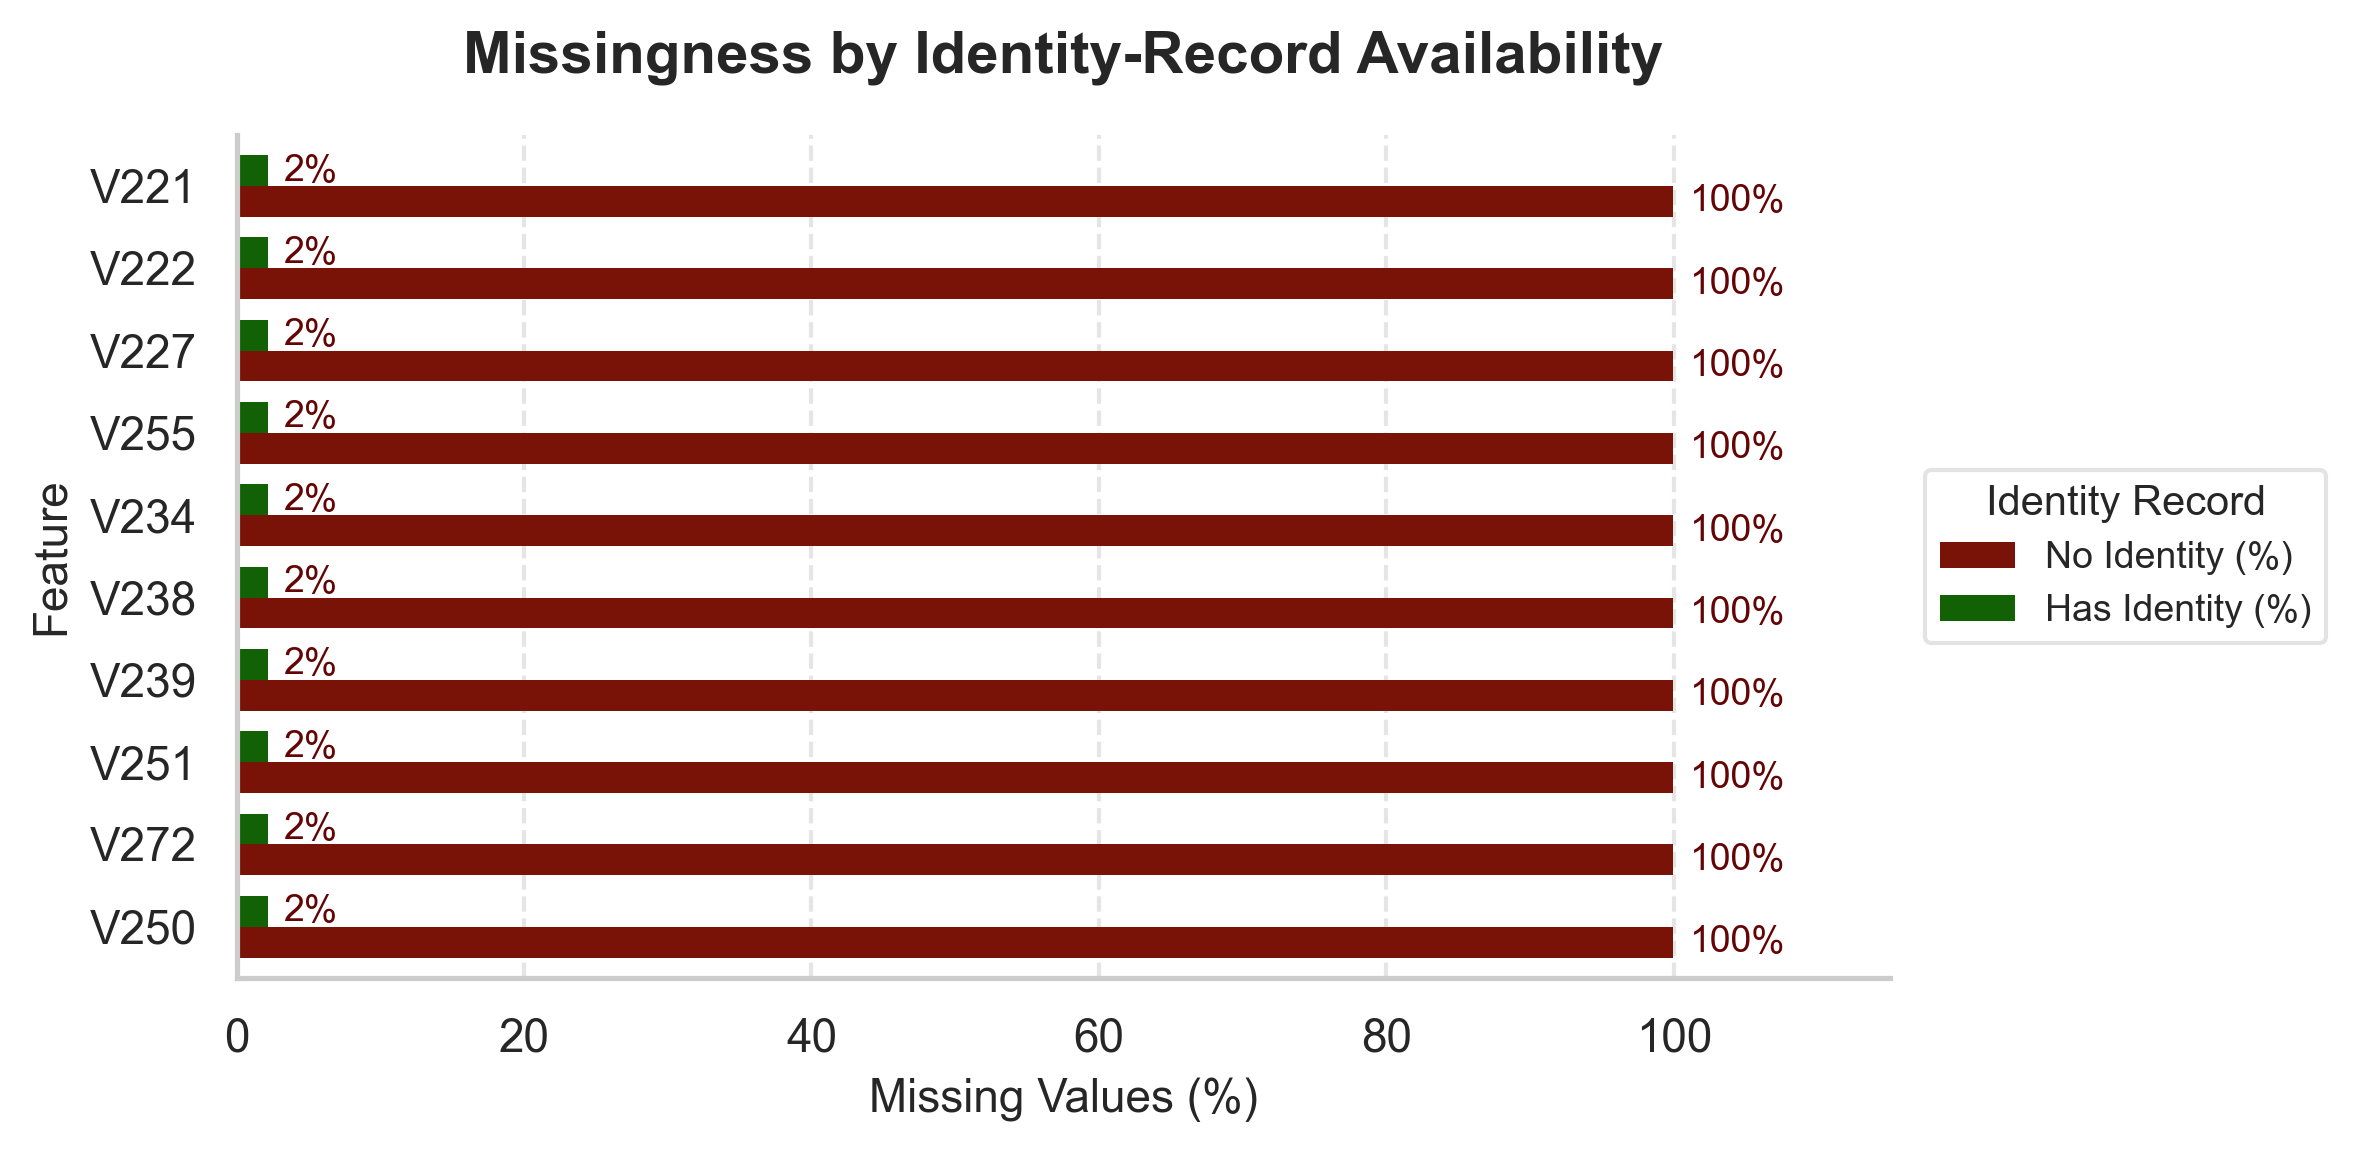

In [86]:
sns.set_theme(style="white")
plot_data = ( missing_by_identity.sort_values("Difference", ascending=False).head(10).sort_values("Difference"))

# Initialize plot with explicit size and high DPI
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
plot_data[["No Identity (%)", "Has Identity (%)"]].plot(kind="barh", ax=ax, width=0.75,color=["#791308", "#126105"], edgecolor="none")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", padding=4, fontsize=9, color="#640404")
ax.set_title("Missingness by Identity-Record Availability", fontsize=14, fontweight="bold", pad=15,)
ax.set_xlabel("Missing Values (%)", fontsize=11, fontweight="medium")
ax.set_ylabel("Feature", fontsize=11, fontweight="medium")
ax.set_xlim(0, 115) 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)
ax.legend(title="Identity Record", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True, facecolor="white", edgecolor="#dddddd", fontsize=9, title_fontsize=10)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.tight_layout()
plt.show()

### 4.1.6 Top 10 features with largest missingness difference

In [26]:
# Top 10 features with largest missingness difference
top_features = (missing_by_identity.sort_values("Difference", ascending=False).head(10).index)
results = []
for feature in top_features:  
    for identity in [0, 1]:   
        subset = df[df["has_identity"] == identity]
        # Feature missing
        missing_rows = subset[subset[feature].isna()]
        results.append({
            "Feature": feature,
            "Identity_Status": "No Identity" if identity == 0 else "Has Identity",
            "Feature_Status": "Missing",
            "Transaction_Count": len(missing_rows),
            "Fraud_Rate (%)": missing_rows["isFraud"].mean() * 100
        })
        # Feature available
        available_rows = subset[subset[feature].notna()]
        results.append({
            "Feature": feature,
            "Identity_Status": "No Identity" if identity == 0 else "Has Identity",
            "Feature_Status": "Available",
            "Transaction_Count": len(available_rows),
            "Fraud_Rate (%)": available_rows["isFraud"].mean() * 100
        })
fraud_missing_identity = pd.DataFrame(results)
display(fraud_missing_identity)

,Feature,Identity_Status,Feature_Status,Transaction_Count,Fraud_Rate (%)
0,V250,No Identity,Missing,445997,2.093512
1,V250,No Identity,Available,310,2.580645
2,V250,Has Identity,Missing,3127,11.000959
3,V250,Has Identity,Available,141106,7.777132
4,V272,No Identity,Missing,445997,2.093512
5,V272,No Identity,Available,310,2.580645
6,V272,Has Identity,Missing,3127,11.000959
7,V272,Has Identity,Available,141106,7.777132
8,V251,No Identity,Missing,445997,2.093512
9,V251,No Identity,Available,310,2.580645


The fraud rates were higher for those transactions where identity information was available. However, for the transactions without identity data, these features were mostly missing, so the comparison was less reliable.

The fraud-only missingness analysis was used for descriptive EDA only. 

### 4.2 Check dataset shape and fraud distribution

In [27]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (590540, 435)
Number of rows: 590540
Number of columns: 435


'has_identity', 'TransactionDay', 'TransactionWeek', 'RelativeWeekday', 'RelativeHour' -- Five columns were added, so the shape became 440

In [28]:
# Check fraud distribution after merge
print("\nFraud distribution:")
print(df["isFraud"].value_counts())

print("\nFraud percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)


Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


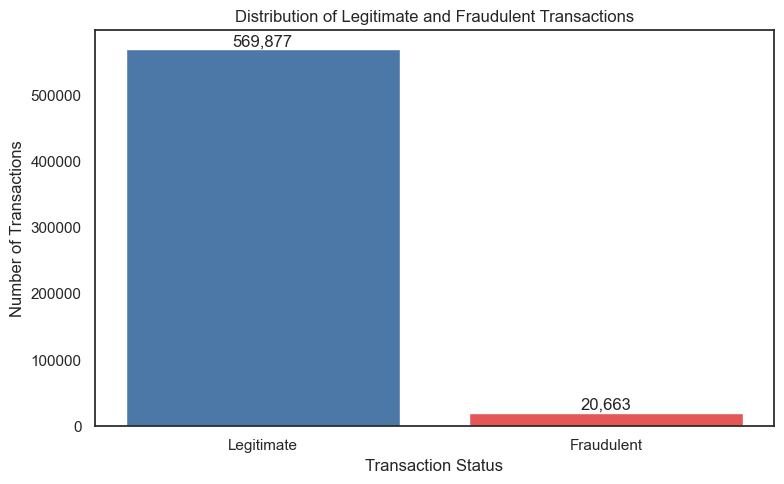

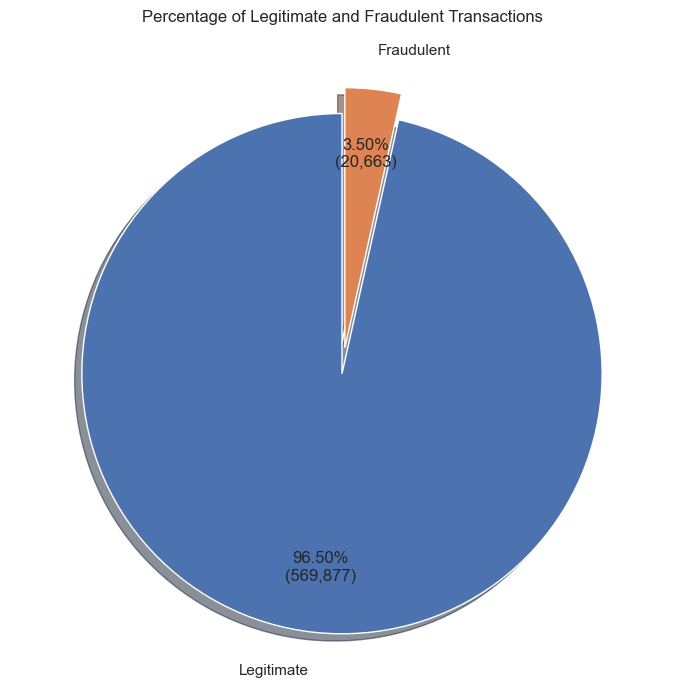

In [29]:
# Count fraud and non-fraud transactions
fraud_counts = df["isFraud"].value_counts().sort_index()

# Change 0 and 1 into readable labels
fraud_counts.index = ["Legitimate", "Fraudulent"]

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar( fraud_counts.index, fraud_counts.values, color=["#4C78A8", "#E45756"])
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height()):,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# Pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.2f}%\n({val:,})"
    return my_autopct
plt.figure(figsize=(7, 7))
plt.pie(fraud_counts.values, labels=fraud_counts.index, autopct=make_autopct(fraud_counts.values), shadow=True, startangle=90, pctdistance=0.75, labeldistance=1.15, explode=(0, 0.1))
plt.title("Percentage of Legitimate and Fraudulent Transactions", y=1.05)
plt.axis("equal")
plt.tight_layout()
plt.show()

The target variable was highly imbalanced: approximately 3.5% of transactions were labelled as fraudulent, while approximately 96.5% were legitimate.

# 5. Feature wise Analysis

## 5.1 TransactionDT: This is timedelta from a given reference datetime
"TransactionDT" did not contain actual timestamp but it records time (elapsed seconds) from a common reference point. Hence, it preserved the chronological order and relative spacing of transactions but actual calendar dates, weekdays and clock times cannot be recovered. Relative transaction days, weeks and repeating time cycles were therefore used for temporal EDA.

### 5.1.1 Total transaction distribution

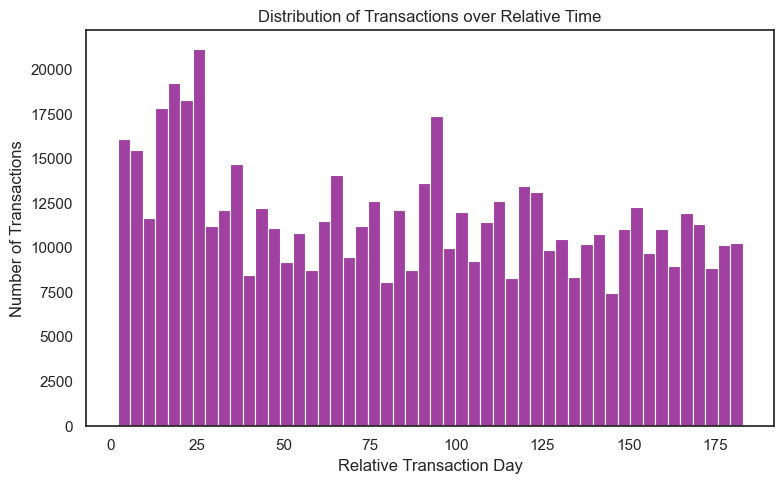

In [30]:
# Convert TransactionDT from seconds into relative days
df["TransactionDay"] = (df["TransactionDT"] // 86400).astype(int) + 1

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="TransactionDay", bins=50, color="purple")
plt.title("Distribution of Transactions over Relative Time")
plt.xlabel("Relative Transaction Day")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Transaction activity varied across the relative observation period, with several periods showing higher transaction volumes. As TransactionDT represents elapsed seconds from an undisclosed reference point, it was converted into relative transaction days for easier interpretation.

### 5.1.2 Fraudulent and Legitimate transaction distribution

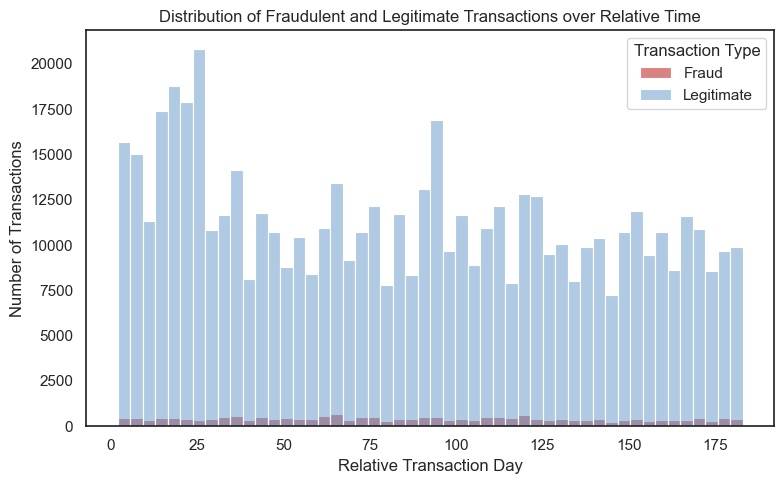

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="TransactionDay", hue="isFraud", bins=50, multiple="layer", alpha=0.5, palette={0: "#6397CB", 1: "#B70606" })
plt.title("Distribution of Fraudulent and Legitimate Transactions over Relative Time")
plt.xlabel("Relative Transaction Day")
plt.ylabel("Number of Transactions")
plt.legend(title="Transaction Type", labels=["Fraud", "Legitimate"])
plt.tight_layout()
plt.show()

The distribution of transactions varied over time. The fradulent transactions were very less compared to legitimate ones.

### 5.1.3 Fraud rate over entire duration

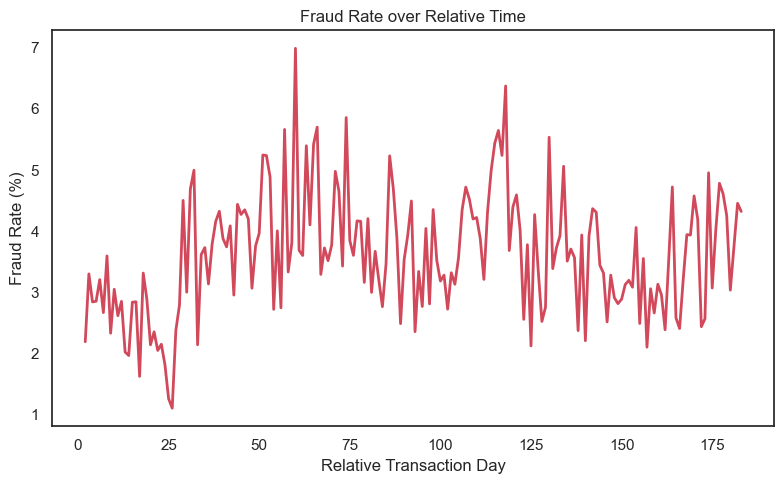

In [32]:
daily_fraud = (df.groupby("TransactionDay")["isFraud"].mean().mul(100).reset_index(name="FraudRate"))

plt.figure(figsize=(8, 5))
sns.lineplot(data=daily_fraud, x="TransactionDay", y="FraudRate", color="#D1495B", linewidth=2)
plt.title("Fraud Rate over Relative Time")
plt.xlabel("Relative Transaction Day")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In the entire duration of time fraud rate varied from 1-7%. There were many spikes observed, hence the fraud rate is not consistent so chronological split can be considered better than random split.

### 5.1.4 Weekly fraud rate

,fraud_rate,transaction_count
TransactionWeek,,
1,2.805544,23810
2,2.614826,27803
3,2.550044,34470
4,1.852299,37251
5,3.822636,24041
6,3.832083,21868
7,3.859357,20392
8,4.119850,20025
9,4.553986,20246


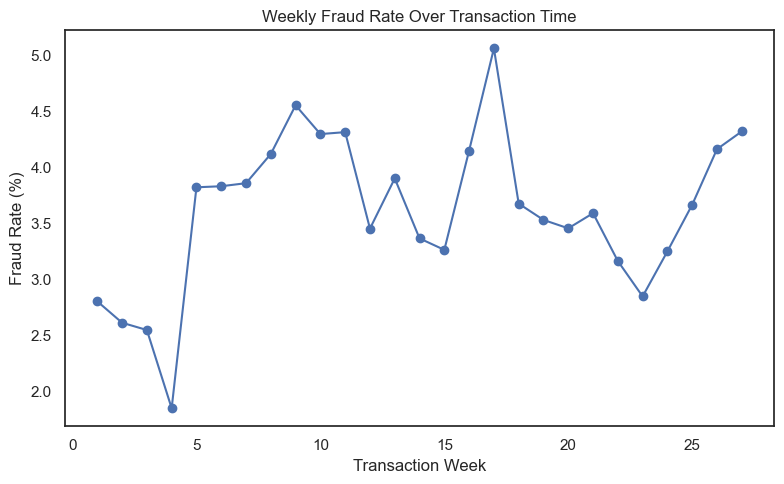

In [33]:
# Create relative transaction week
df["TransactionWeek"] = ((df["TransactionDay"] - 1) // 7).astype(int) + 1

# Calculate weekly transaction count and fraud rate
weekly_summary = (df.groupby("TransactionWeek")["isFraud"].agg(fraud_rate="mean",transaction_count="count"))

# Convert fraud rate into percentage
weekly_summary["fraud_rate"] *= 100

display(weekly_summary)

# Plot weekly fraud rate
plt.figure(figsize=(8, 5))
plt.plot(weekly_summary.index, weekly_summary["fraud_rate"], marker="o")
plt.title("Weekly Fraud Rate Over Transaction Time")
plt.xlabel("Transaction Week")
plt.ylabel("Fraud Rate (%)")
plt.grid(False)
plt.tight_layout()
plt.show()

### 5.1.5 Transaction Volume and Fraud Rate by Relative Seven-Day Cycle

,RelativeWeekday,Number of Transactions,Fraud Percentage
0,0,86377,3.717425
1,1,98502,3.603988
2,2,79834,3.711451
3,3,70223,3.564359
4,4,85433,3.145155
5,5,84815,3.304840
6,6,85356,3.451427


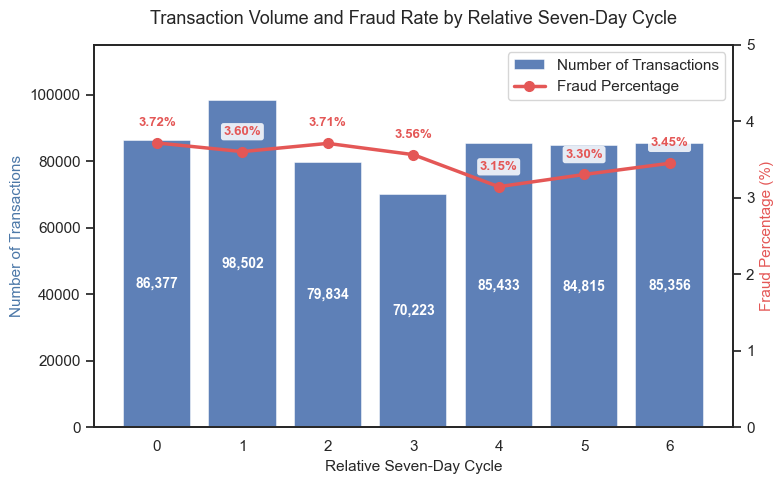

In [34]:
# Feature Engineering: Relative weekday (0-6)
df["RelativeWeekday"] = (df["TransactionDT"] // 86400) % 7

# Calculate count and fraud rate together
tmp = (df.groupby("RelativeWeekday").agg(**{"Number of Transactions": ("TransactionID", "count"), "Fraud Percentage": ("isFraud", lambda x: x.mean() * 100),}).reset_index())

display(tmp)

fig, ax1 = plt.subplots(figsize=(8, 5))
# Primary Axis: Bars for Transaction Counts
bars = ax1.bar(tmp["RelativeWeekday"], tmp["Number of Transactions"],edgecolor="white", linewidth=1.2, alpha=0.9,label="Number of Transactions")
ax1.set_xlabel("Relative Seven-Day Cycle", fontsize=11)
ax1.set_ylabel("Number of Transactions", color="#4C78A8", fontsize=11)
ax1.set_xticks(range(7))
ax1.set_ylim(0, 115000)
ax1.bar_label(bars, fmt="{:,.0f}", label_type="center", fontsize=10, color="white", fontweight="bold")

# Secondary Axis: Line for Fraud Percentage
ax2 = ax1.twinx()
ax2.plot(tmp["RelativeWeekday"], tmp["Fraud Percentage"], color="#E45756", marker="o", markersize=7, linewidth=2.5, label="Fraud Percentage")
ax2.set_ylabel("Fraud Percentage (%)", color="#E45756", fontsize=11)
ax2.set_ylim(0, 5)

# Annotate red percentages cleanly above the line markers
for x, y in zip(tmp["RelativeWeekday"], tmp["Fraud Percentage"]):
    ax2.annotate(f"{y:.2f}%", xy=(x, y), xytext=(0, 10), textcoords="offset points", ha="center", va="bottom", fontsize=9.5, color="#E45756", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85,))

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")
plt.title("Transaction Volume and Fraud Rate by Relative Seven-Day Cycle", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

The number of transactions was different across the seven relative time groups, ranging from around 70,000 to 98,500. The fraud percentage did not change very much and stayed between about 3.15% and 3.72%. Groups 0 and 2 had the highest fraud rates, while group 4 had the lowest. These groups are only based on a repeating seven-day cycle from an unknown starting point, so they cannot be treated as actual weekdays such as Monday or Tuesday.

### 5.1.6 Transaction Volume and Fraud Rate by Relative 24-Hour Cycle

,RelativeHour,Number_of_Transactions,Fraud_Percentage
0,0,37795,3.137981
1,1,32797,3.131384
2,2,26732,3.748317
3,3,20802,3.831362
4,4,14839,5.189029
5,5,9701,7.030203
6,6,6007,7.774263
7,7,3704,10.610151
8,8,2591,9.301428
9,9,2479,8.995563


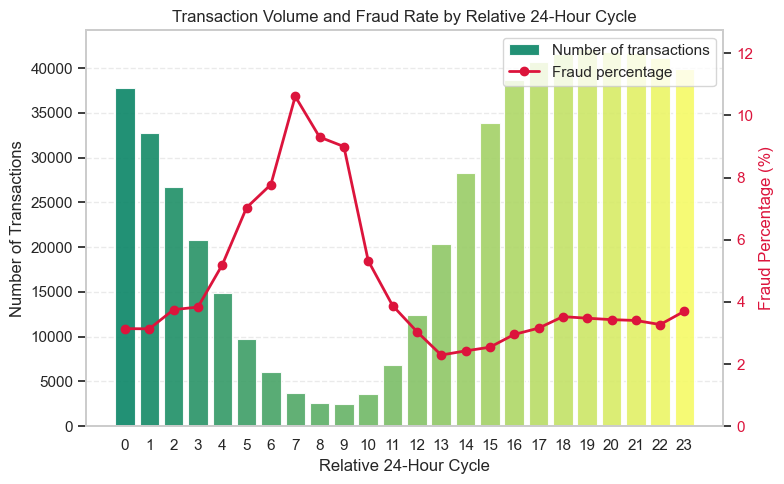

In [35]:
# Creating 24 repeating hourly groups(These are relative hourly groups, not actual clock hours)
df["RelativeHour"] = ((df["TransactionDT"] // 3600) % 24).astype(int)

# Calculate fraud percentage for each relative hour
hourly_summary = (df.groupby("RelativeHour").agg(Number_of_Transactions=("TransactionID", "count"), Fraud_Percentage=("isFraud", "mean")).reset_index())

# Convert fraud proportion into percentage
hourly_summary["Fraud_Percentage"] *= 100
display(hourly_summary)

sns.set_theme(style="whitegrid")
summer_colors = sns.color_palette("summer",n_colors=len(hourly_summary))

fig, ax1 = plt.subplots(figsize=(8, 5))
# Bar chart for transaction count
bars = ax1.bar(hourly_summary["RelativeHour"], hourly_summary["Number_of_Transactions"], color=summer_colors, alpha=0.9,linewidth=0.8, label="Number of transactions")

ax1.set_xlabel("Relative 24-Hour Cycle")
ax1.set_ylabel("Number of Transactions")
ax1.set_xticks(range(24))

# Fraud percentage on second axis
ax2 = ax1.twinx()
ax2.plot(hourly_summary["RelativeHour"], hourly_summary["Fraud_Percentage"], color="crimson", marker="o", linewidth=2, label="Fraud percentage")
ax2.set_ylabel("Fraud Percentage (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, hourly_summary["Fraud_Percentage"].max() * 1.2)
plt.title( "Transaction Volume and Fraud Rate by Relative 24-Hour Cycle")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.grid(axis="x", visible=False)
ax2.grid(False)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2,labels1 + labels2,loc="upper right")
plt.tight_layout()
plt.show()


Transaction volume changed considerably across the 24 relative hourly groups. The lowest number of transactions occurred around groups 7 to 10, while the highest transaction volumes were recorded around groups 18 to 22. The fraud rate was highest around groups 7 to 9 and lowest around groups 13 to 15. These groups are based on an unknown reference time, so they cannot be interpreted as actual clock hours.

## 5.2 TransactionAmt: This is the amount associated with each transaction. 

TransactionAmt contains no missing values.

In [36]:
df['TransactionAmt'].isnull().sum()

np.int64(0)

### 5.2.1 Transaction Amount Distribution for Transactions

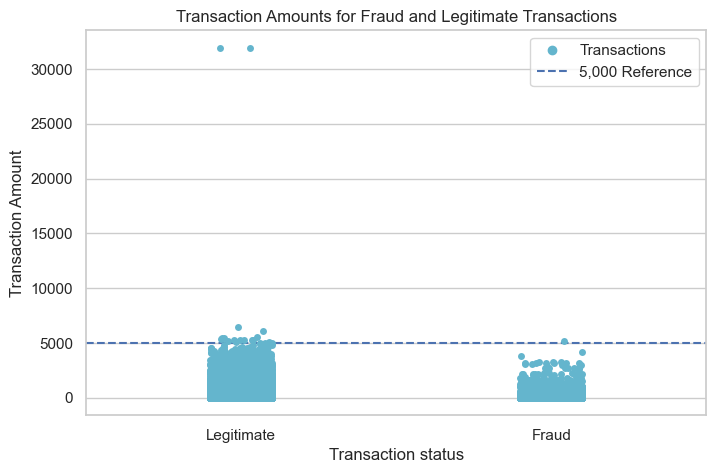

In [37]:
import matplotlib.lines as mlines

plt.figure(figsize=(8, 5))
plt.subplot(111)
sns.stripplot(y='TransactionAmt', x='isFraud', data=df, color = 'c')
plt.axhline(5000, color='b', linestyle="--", label="5,000 Reference")
points_handle = mlines.Line2D([], [], color="c", marker="o", linestyle="None", markersize=6, label="Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title('Transaction Amounts for Fraud and Legitimate Transactions')
plt.ylabel("Transaction Amount")
plt.xlabel("Transaction status")
plt.legend(handles=[points_handle, plt.gca().get_legend_handles_labels()[0][0]], loc="upper right")
plt.show()

Most fraud and non-fraud transactions had amounts below 5,000. A small number of non-fraud transactions had much higher amounts, including two transactions above 30,000. Fraudulent transactions generally had lower amounts, with most remaining below 4,000 and only a small number reaching around 5,000. This shows that the transaction amount distribution contains some extreme outliers, especially among non-fraud transactions.

### 5.2.2 Transaction Amount Distribution over time for fraudulent and legitimate transactions

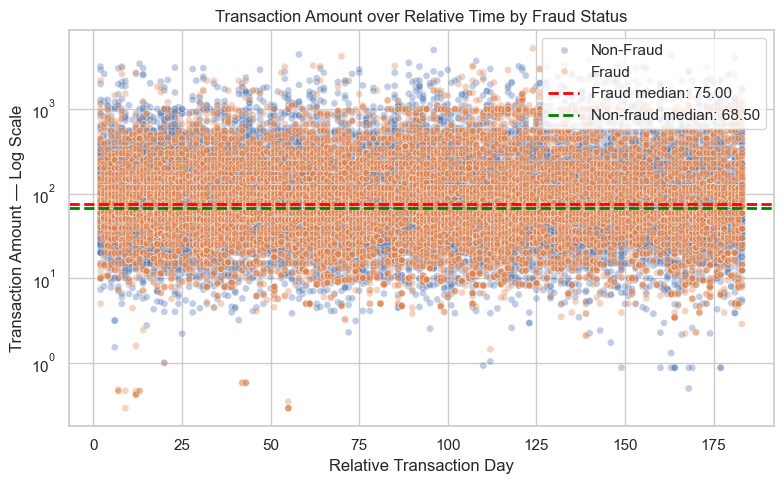

In [38]:
# Create readable fraud labels
df["Fraud Status"] = df["isFraud"].map({0: "Non-Fraud", 1: "Fraud"})

# Select fraud transactions and non-fraud transactions
fraud_data = df[df["isFraud"] == 1]
non_fraud_data = df[df["isFraud"] == 0].sample(n=min(30000, (df["isFraud"] == 0).sum()), random_state=42)

plot_data = pd.concat([non_fraud_data, fraud_data], ignore_index=True)
fraud_median = df.loc[df["isFraud"] == 1, "TransactionAmt"].median()
non_fraud_median = df.loc[df["isFraud"] == 0, "TransactionAmt"].median()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_data, x="TransactionDay", y="TransactionAmt", hue="Fraud Status", alpha=0.35, s=25)
plt.axhline(fraud_median, color="red", linestyle="--", linewidth=2, label=f"Fraud median: {fraud_median:.2f}")
plt.axhline(non_fraud_median, color="green", linestyle="--", linewidth=2, label=f"Non-fraud median: {non_fraud_median:.2f}")
plt.yscale("log")
plt.title("Transaction Amount over Relative Time by Fraud Status")
plt.xlabel("Relative Transaction Day")
plt.ylabel("Transaction Amount — Log Scale")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Transaction amounts were spread across the full relative observation period for both fraud and non-fraud transactions. Most transactions had relatively low amounts, while a small number of transactions had very high values. Fraud and non-fraud transactions also showed considerable overlap, meaning that transaction amount alone may not be enough to separate the two classes. A logarithmic scale was used because the transaction amounts were highly skewed and contained extreme values.

### 5.2.3 Trascation Amount ditribution by Fraud Status

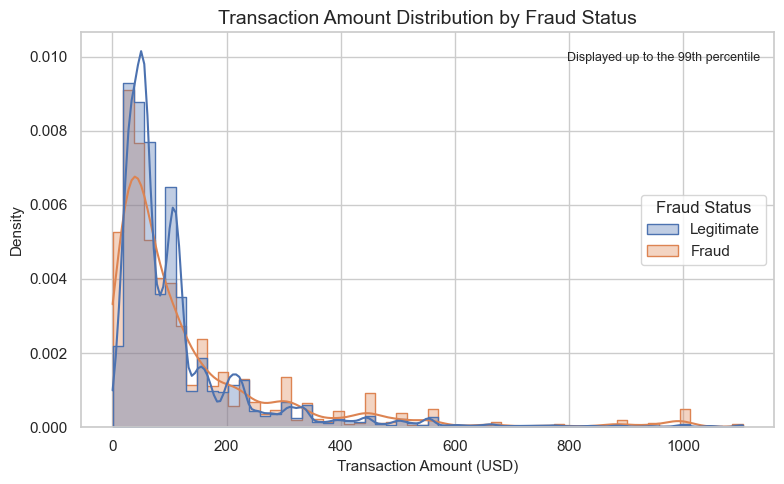

In [39]:
amount_99 = df["TransactionAmt"].quantile(0.99)

plot_df = df[df["TransactionAmt"] <= amount_99].copy()
plot_df["Fraud Status"] = plot_df["isFraud"].map({
    0: "Legitimate",
    1: "Fraud"
})
plt.figure(figsize=(8, 5))
sns.histplot(data=plot_df, x="TransactionAmt", hue="Fraud Status", bins=60, stat="density", common_norm=False, element="step", alpha=0.35, kde=True)
plt.title("Transaction Amount Distribution by Fraud Status", fontsize=14)
plt.xlabel("Transaction Amount (USD)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.text(0.98, 0.95, "Displayed up to the 99th percentile", transform=plt.gca().transAxes, ha="right", va="top", fontsize=9)
plt.tight_layout()
plt.show()

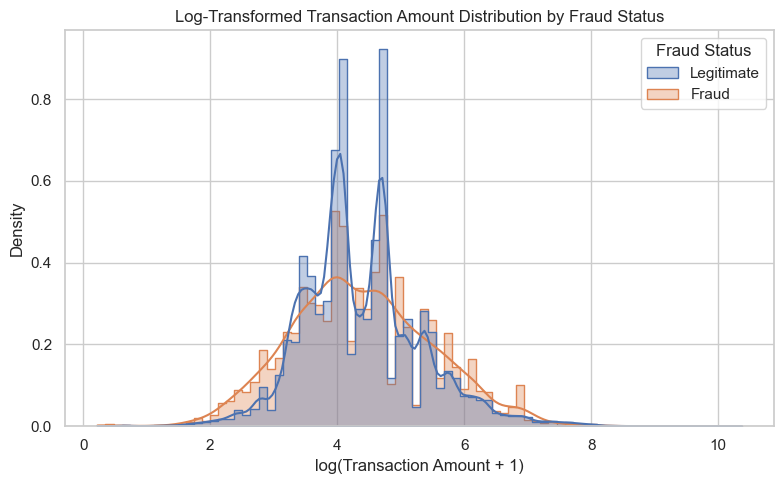

In [40]:
# Transaction amount distribution using log transformation
plot_df = df.copy()
plot_df["Fraud Status"] = plot_df["isFraud"].map({
    0: "Legitimate",
    1: "Fraud"
})
plot_df["LogTransactionAmt"] = np.log1p(plot_df["TransactionAmt"])
plt.figure(figsize=(8, 5))
sns.histplot(data=plot_df, x="LogTransactionAmt", hue="Fraud Status", stat="density", common_norm=False, bins=80, kde=True, kde_kws={"bw_adjust": 1.5}, element="step", alpha=0.35)
plt.title("Log-Transformed Transaction Amount Distribution by Fraud Status")
plt.xlabel("log(Transaction Amount + 1)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

### 5.2.3 Outlier Checking using InterQuartile Method

In [41]:
# Check for outliers in TransactionAmt using IQR method
Q1 = df["TransactionAmt"].quantile(0.25)
Q3 = df["TransactionAmt"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["TransactionAmt"] < lower_bound) | (df["TransactionAmt"] > upper_bound)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper outlier threshold:", upper_bound)
print("Number of outliers:", len(outliers))
print("Outlier percentage:", len(outliers) / len(df) * 100)

Q1: 43.321
Q3: 125.0
IQR: 81.679
Upper outlier threshold: 247.51850000000002
Number of outliers: 66482
Outlier percentage: 11.257831814949029


By using  1.5 × IQR rule, 66,482 transactions (11.26%) were identified as transaction-amount outliers. These observations were not removed because these transactions may contain useful information about fraud detection.

The transaction amount distribution was highly skewed, so a log transformation was applied for visualisation. Since legitimate transactions was more than fraudulent transactions, density was used instead of raw frequency. This made it easier to compare the shape of the transaction amount distribution between fraud and legitimate classes.

## 5.3 ProductCD: Product Code Associated with Each Transaction



In [42]:
df['ProductCD'].isnull().sum()

np.int64(0)

ProductCD had no missing values

### 5.3.1 Trascation distribution across Product Code

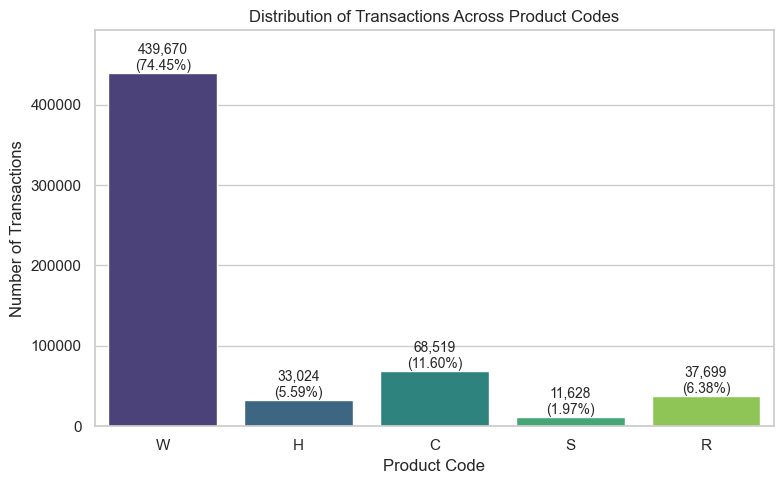

In [43]:
fig, axes = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="ProductCD", hue="ProductCD", palette="viridis", legend=False, ax=axes)
axes.set_title("Distribution of Transactions Across Product Codes")
axes.set_xlabel("Product Code")
axes.set_ylabel("Number of Transactions")

# Total number of transactions with a ProductCD value
total_transactions = df["ProductCD"].notna().sum()
# Add count and percentage above each bar
for bar in axes.patches:
    count = int(bar.get_height())
    percentage = count / total_transactions * 100
    axes.text(bar.get_x() + bar.get_width() / 2, count, f"{count:,}\n({percentage:.2f}%)", ha="center", va="bottom", fontsize=10)
axes.set_ylim(0, max(bar.get_height() for bar in axes.patches) * 1.12)

plt.tight_layout()
plt.show()

The distribution of transactions was not equal across the five product-code categories. Product code W had the highest number of transactions and represented most of the dataset. Product code C had the second-highest count, while R and H had much smaller numbers of transactions. Product code S had the lowest number of transactions. This shows that the ProductCD feature is highly imbalanced, with category W dominating the dataset.

### 5.3.2 Legitimate and Fraudulent distribution across Product Code

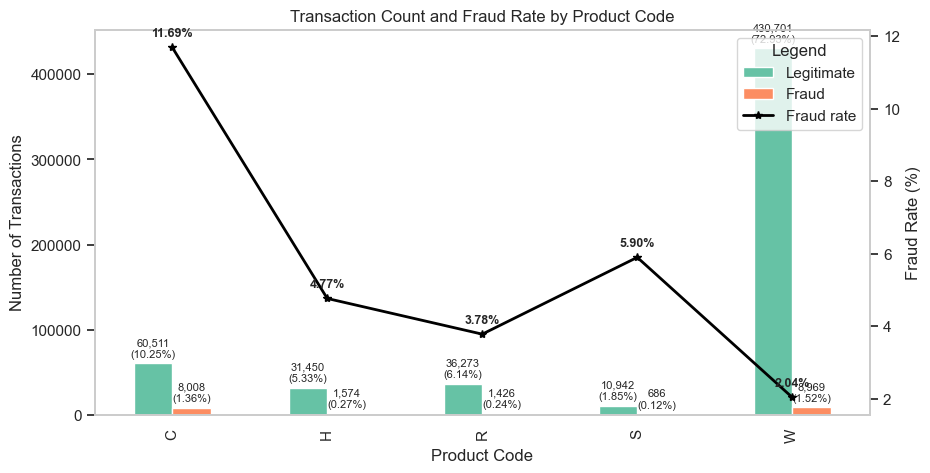

<Figure size 800x500 with 0 Axes>

In [44]:
# Count legitimate and fraud transactions for each ProductCD
product_summary = pd.crosstab(df["ProductCD"], df["isFraud"]).rename(columns={0: "Legitimate", 1: "Fraud"})

# Fraud rate for each ProductCD
fraud_rate = (product_summary["Fraud"] / product_summary.sum(axis=1) * 100)
# Bar chart
ax = product_summary.plot(kind="bar", figsize=(10, 5), color=sns.color_palette("Set2", 2))
plt.figure(figsize=(8, 5))
# Add count and percentage to bars
total = product_summary.to_numpy().sum()
for container in ax.containers:
    labels = [
        f"{int(value):,}\n({value / total * 100:.2f}%)"
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

# Fraud-rate line
ax2 = ax.twinx()
ax2.plot(range(len(fraud_rate)), fraud_rate.values, color="black", marker="*", linewidth=2, label="Fraud rate")
# Add fraud-rate percentage labels
for i, rate in enumerate(fraud_rate.values):
    ax2.annotate(f"{rate:.2f}%", (i, rate), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

# Titles and labels
ax2.set_ylabel("Fraud Rate (%)")
ax.set_title("Transaction Count and Fraud Rate by Product Code")
ax.set_xlabel("Product Code")
ax.set_ylabel("Number of Transactions")
ax2.set_ylabel("Fraud Rate (%)")
ax.grid(False)
ax2.grid(False)

# Combine legends from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, title="Legend", loc="upper right")
plt.tight_layout()
plt.show()

Product code W had the highest number of transactions and represented most of the dataset. However, it had the lowest fraud rate at approximately 2.04%. Product code C had the highest fraud rate at approximately 11.69%, followed by S at 5.90% and H at 4.77%. This showed that a product code with a high transaction volume does not necessarily have a high fraud rate.

## 5.3 Card 1-6

All six card variables were retained as categorical features. Visual analysis was focused on card4 and card6 because they contain a small number of directly interpretable categories, whereas the remaining card variables contain substantially more coded values.

### 5.3.1  Card features analysis 

In [45]:
# Card features analysis    
cards = [col for col in df.columns if 'card' in col]
df[cards].head()

,card1,card2,card3,card4,card5,card6
0,13926,NaN,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


### 5.3.2 Missingess data in Card Features

In [46]:
card_features = ["card1", "card2", "card3", "card4", "card5", "card6"]

card_missing = pd.DataFrame({
    "Missing Count": df[card_features].isnull().sum(),
    "Missing Percentage": (
        df[card_features].isnull().mean() * 100
    ).round(4)
})

display(card_missing)

,Missing Count,Missing Percentage
card1,0,0.0000
card2,8933,1.5127
card3,1565,0.2650
card4,1577,0.2670
card5,4259,0.7212
card6,1571,0.2660


### 5.3.3 Fraud status for card4 and card6

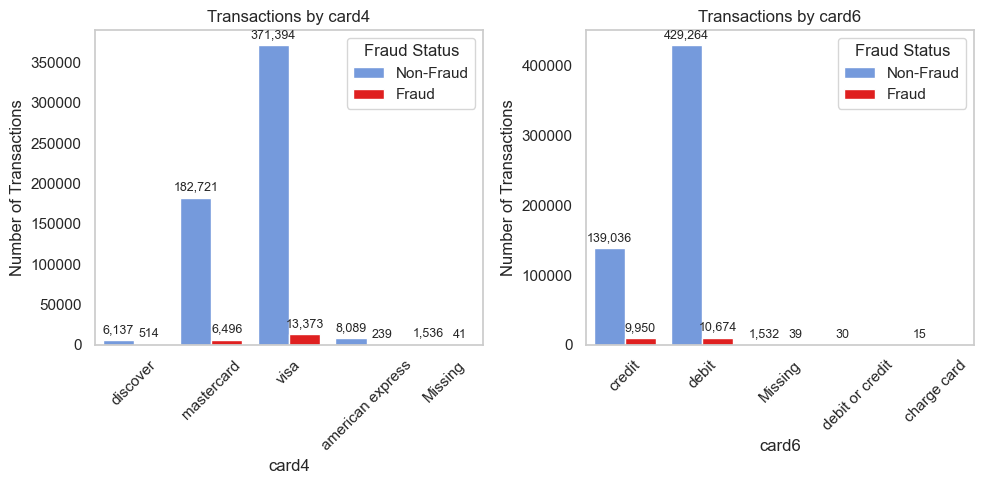

In [47]:
card_features = ["card4", "card6"]

# Replace missing values only in card4 and card6
df[card_features] = (df[card_features].astype("string").fillna("Missing"))
colors = {"Non-Fraud": "cornflowerblue", "Fraud": "red"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for feature, ax in zip(card_features, axes):
    sns.countplot(data=df, x=feature, hue="Fraud Status", palette=colors, ax=ax)
    for container in ax.containers:
        labels = [
            f"{int(value):,}" if value > 0 else ""
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)
    ax.set_title(f"Transactions by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Transactions")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(False)
plt.tight_layout()
plt.show()

The distribution of transactions differed across the card4 and card6 categories. For card4, Visa had the highest number of transactions, followed by Mastercard, while Discover and American Express were much less common. For card6, most transactions were made using debit cards, followed by credit cards. Fraudulent transactions were much fewer than non-fraudulent transactions in every category, showing the strong class imbalance in the dataset. The newly created Missing category contained only a small number of transactions.

## 5.4 P_emailDomain and R_emailDomain

Email domains of the purchaser and recipient.

### 5.4.1 Fraud status for Purchaser Email Domain

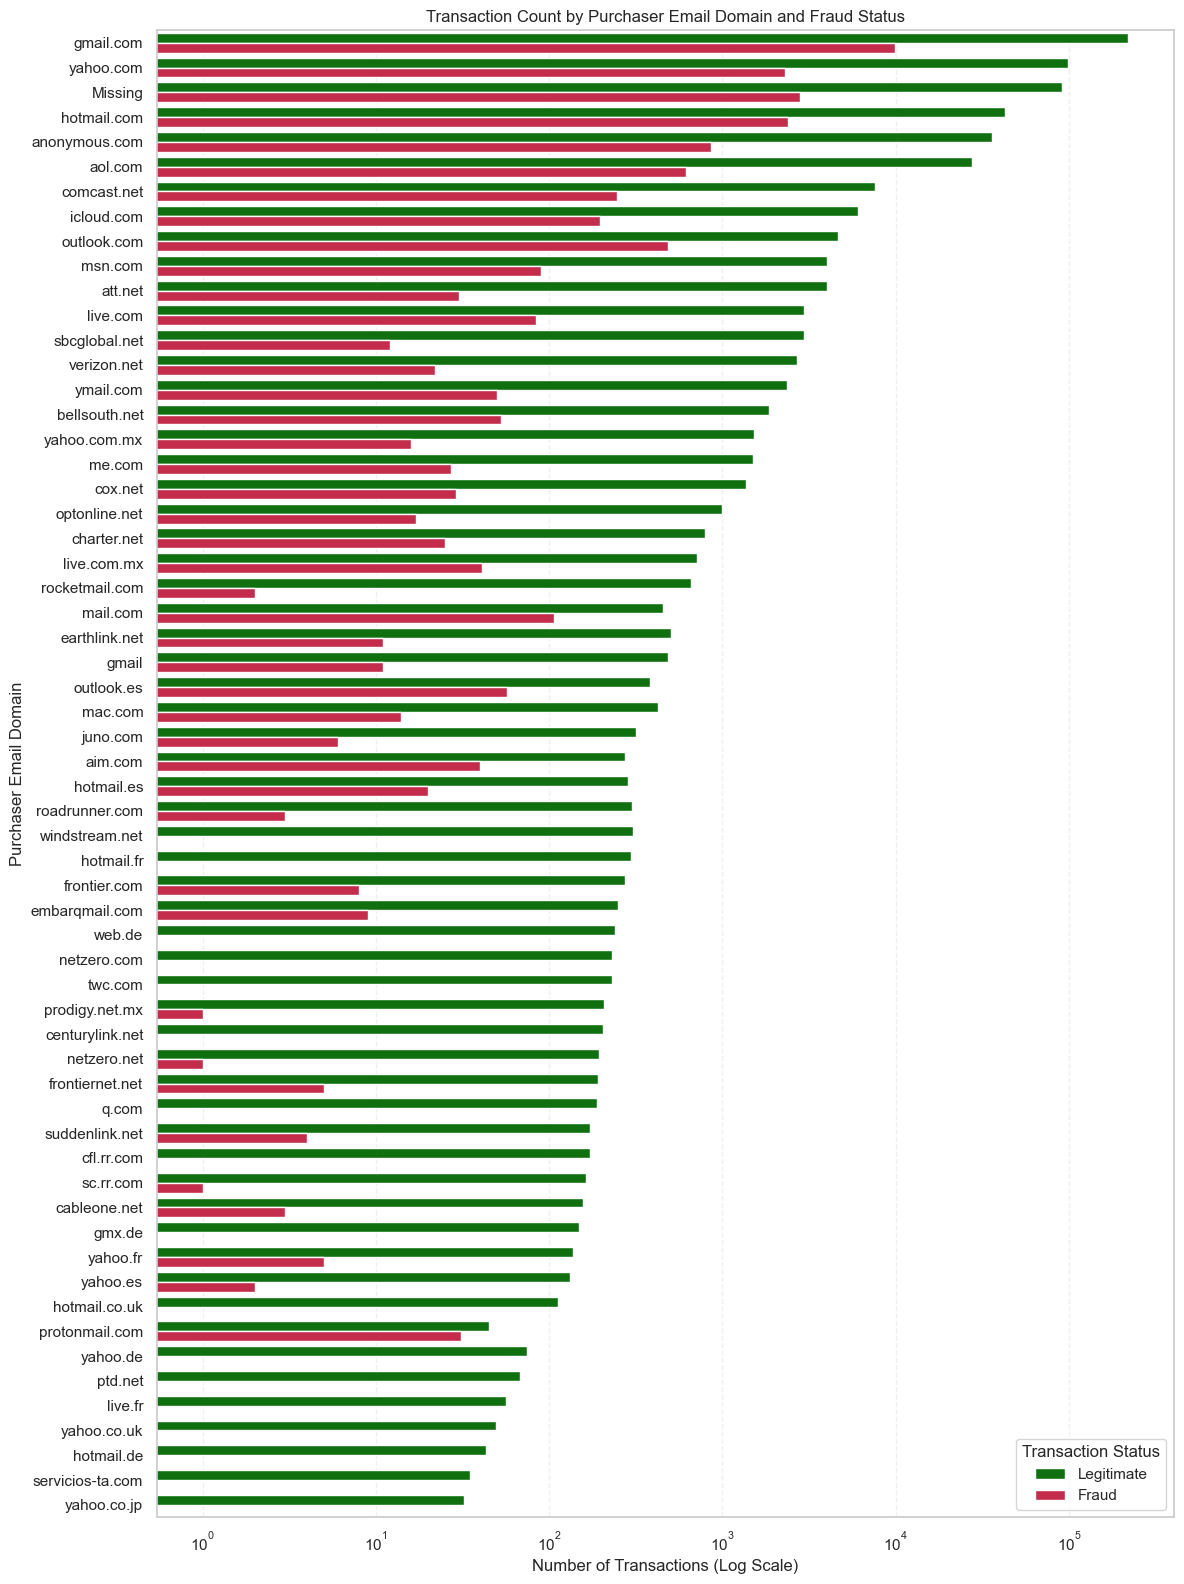

In [48]:
email_data = df.copy()

# Fill missing email domains
email_data["P_emaildomain"] = (email_data["P_emaildomain"].fillna("Missing"))
email_data["Fraud Status"] = (email_data["isFraud"].map({0: "Legitimate", 1: "Fraud"}))

# Purchaser email domains by total transactions
P_email_order = (email_data["P_emaildomain"].value_counts().index)

plt.figure(figsize=(12, 16))
sns.countplot(data=email_data, y="P_emaildomain", hue="Fraud Status", order=P_email_order, palette={"Legitimate": "green", "Fraud": "crimson"})
plt.title("Transaction Count by Purchaser Email Domain and Fraud Status",)
plt.xlabel("Number of Transactions (Log Scale)")
plt.xscale("log")
plt.ylabel("Purchaser Email Domain")
plt.legend(title="Transaction Status")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4.2 Fraud status for Receiver Email Domain

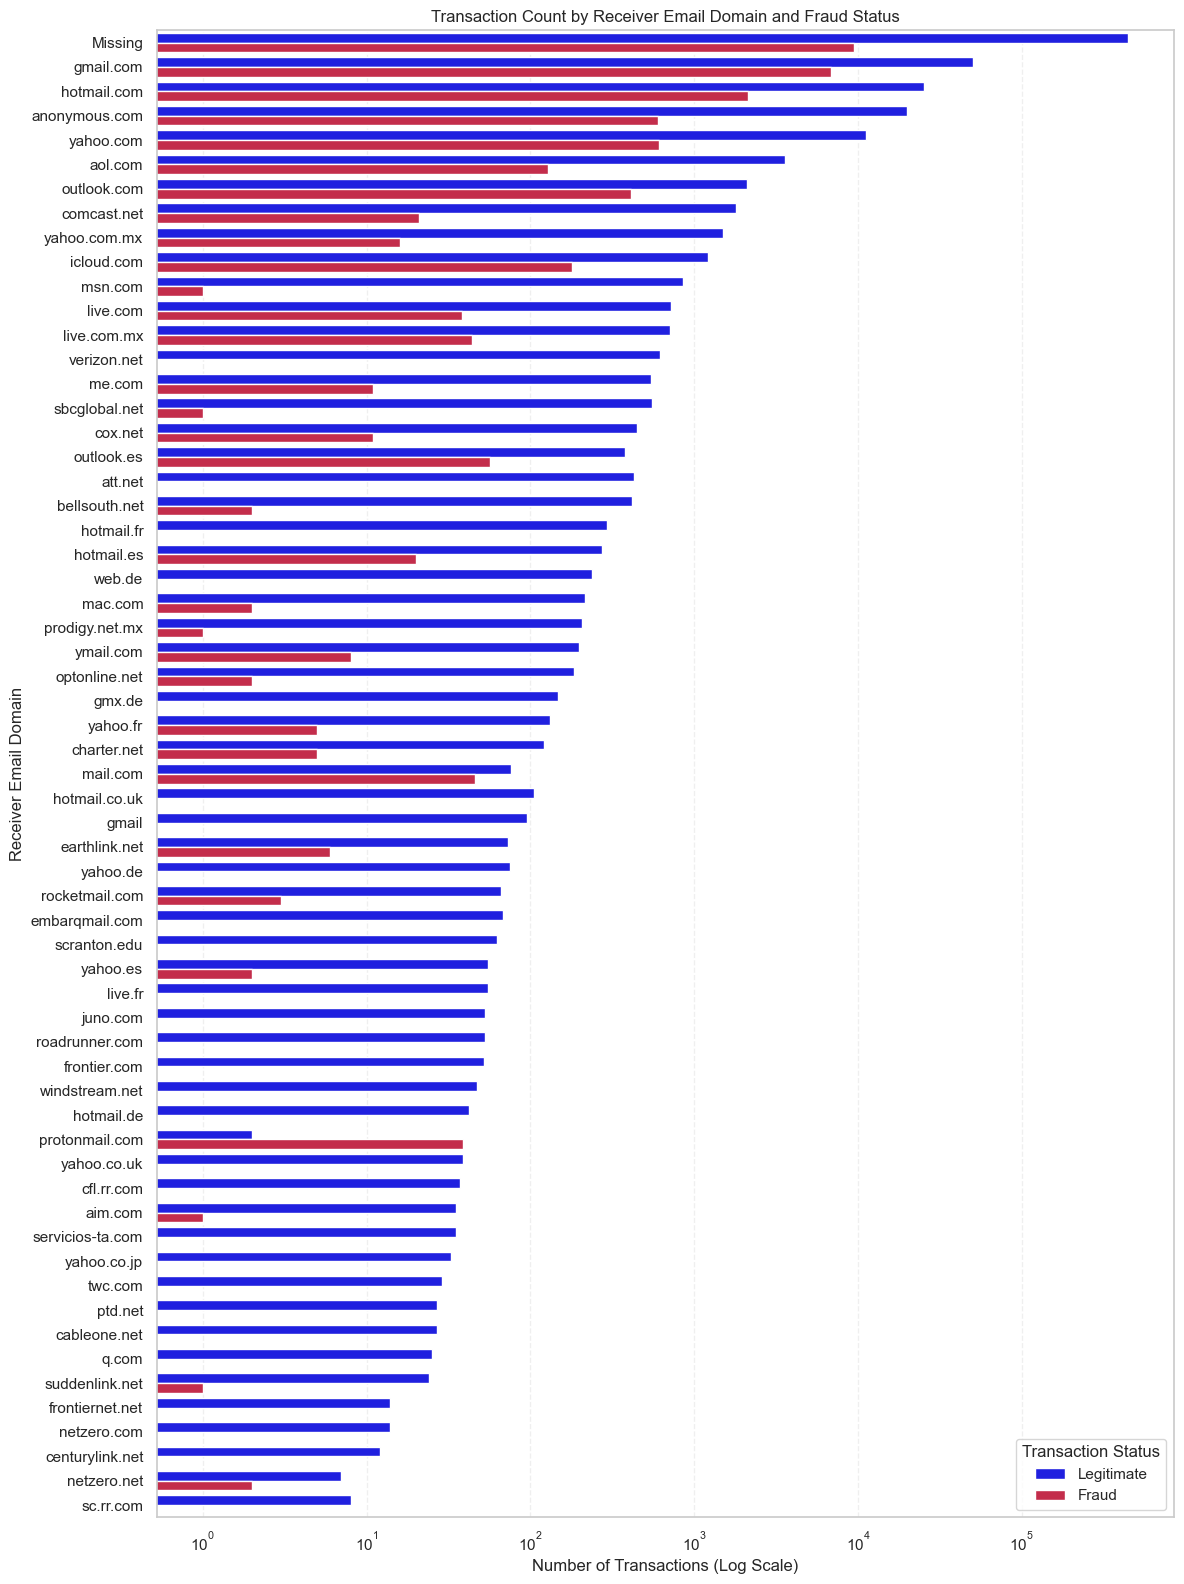

In [49]:
# Fill missing email domains
email_data["R_emaildomain"] = (email_data["R_emaildomain"].fillna("Missing"))

# Receiver email domains by total transactions
R_email_order = (email_data["R_emaildomain"].value_counts().index)

plt.figure(figsize=(12, 16))
sns.countplot(data=email_data, y="R_emaildomain", hue="Fraud Status", order=R_email_order, palette={"Legitimate": "blue", "Fraud": "crimson"})
plt.title("Transaction Count by Receiver Email Domain and Fraud Status")
plt.xlabel("Number of Transactions (Log Scale)")
plt.xscale("log")
plt.ylabel("Receiver Email Domain")
plt.legend(title="Transaction Status")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4.3 Fraud percentage for Purchaser Email Domain

,Transaction_Count,Fraud_Rate
P_emaildomain,,
hotmail.de,43,0.000000
hotmail.co.uk,112,0.000000
yahoo.co.jp,32,0.000000
windstream.net,305,0.000000
hotmail.fr,295,0.000000
web.de,240,0.000000
yahoo.de,74,0.000000
gmx.de,149,0.000000
cfl.rr.com,172,0.000000


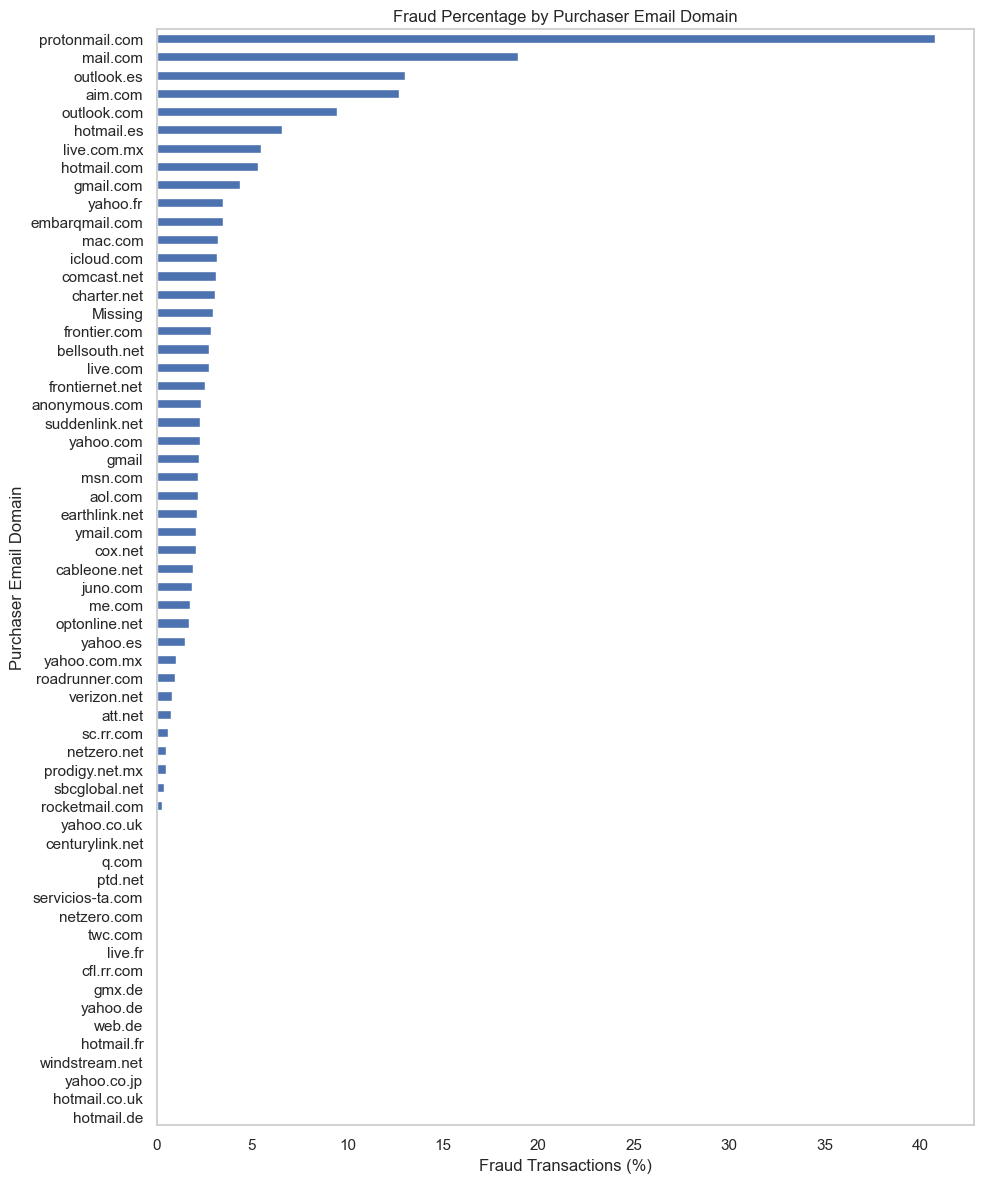

In [50]:
# Purchaser email domain analysis
p_email_summary = (email_data.groupby("P_emaildomain")["isFraud"].agg(Transaction_Count="count",Fraud_Rate="mean"))
p_email_summary["Fraud_Rate"] *= 100

p_email_summary = p_email_summary.sort_values("Fraud_Rate")
display(p_email_summary)

plt.figure(figsize=(10, 12))
ax = p_email_summary["Fraud_Rate"].plot(kind="barh")
ax.set_title("Fraud Percentage by Purchaser Email Domain")
ax.set_xlabel("Fraud Transactions (%)")
ax.set_ylabel("Purchaser Email Domain")
ax.grid(False)
plt.tight_layout()
plt.show()

### 5.4.4 Fraud percentage for Receiver Email Domain

,Transaction_Count,Fraud_Rate
R_emaildomain,,
hotmail.de,42,0.000000
web.de,237,0.000000
juno.com,53,0.000000
windstream.net,47,0.000000
hotmail.fr,293,0.000000
...,...,...
outlook.es,433,13.163972
outlook.com,2507,16.513761
netzero.net,9,22.222222


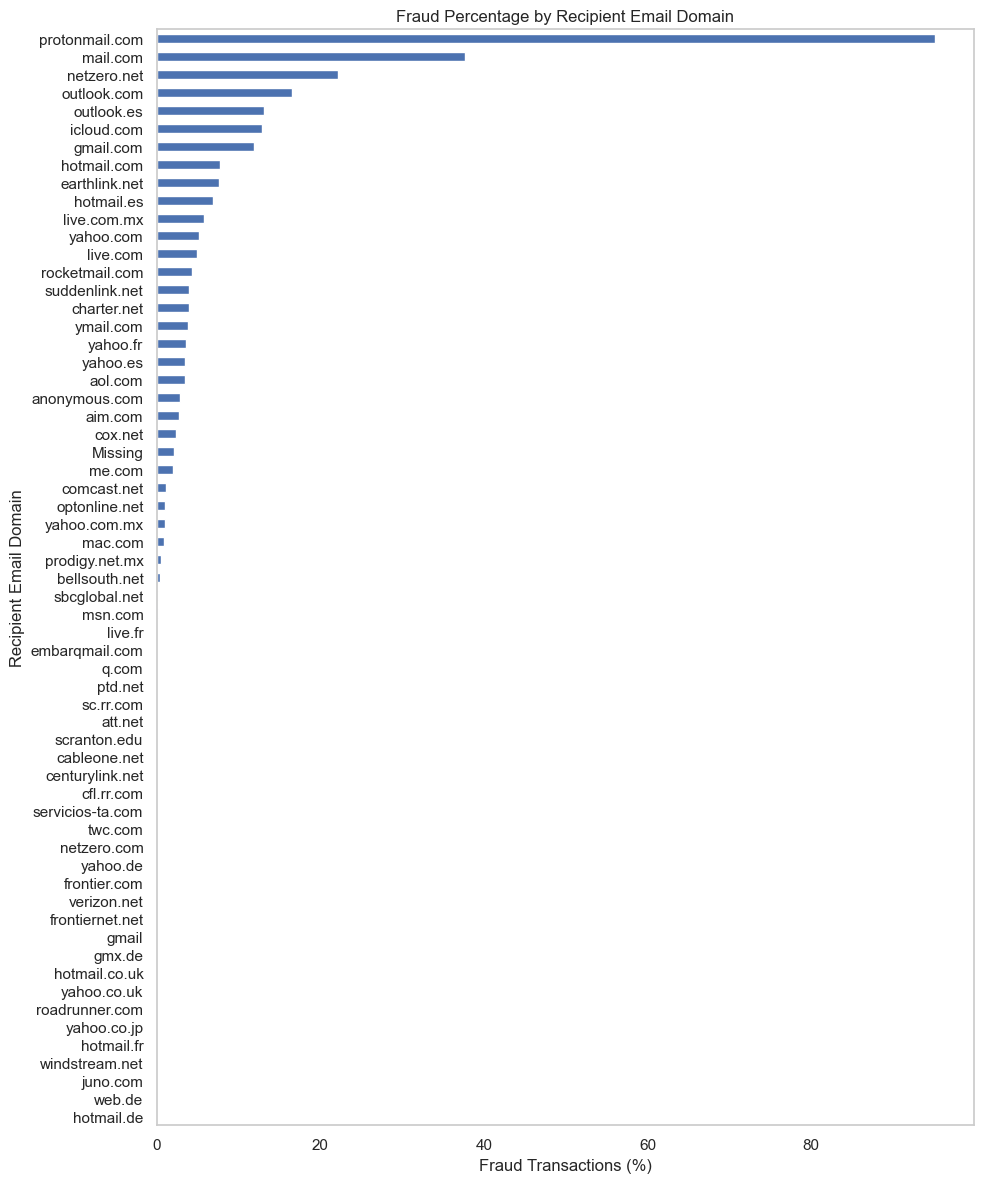

In [51]:
# Recipient email domain analysis
r_email_summary = (email_data.groupby("R_emaildomain")["isFraud"].agg(Transaction_Count="count", Fraud_Rate="mean"))
r_email_summary["Fraud_Rate"] *= 100

r_email_summary = r_email_summary.sort_values("Fraud_Rate")
display(r_email_summary)

plt.figure(figsize=(10, 12))
ax = r_email_summary["Fraud_Rate"].plot(kind="barh")
ax.set_title("Fraud Percentage by Recipient Email Domain")
ax.set_xlabel("Fraud Transactions (%)")
ax.set_ylabel("Recipient Email Domain")
ax.grid(False)
plt.tight_layout()
plt.show()

Fraud rates varied across purchaser and recipient email domains. ProtonMail showed the highest observed fraud percentage in both analyses. However, ProtonMail occurred in relatively few transactions, so these high percentages should be interpreted cautiously.

Common domains such as Gmail, Yahoo and Hotmail had substantially larger sample sizes and generally lower observed fraud rates. Overall, email-domain information may provide useful predictive information, although fraud-rate estimates for rare domains are less stable.

## 5.5 Addr1, Addr2: Categorical data giving address information

### 5.5.1 Checking for null values in address information

In [52]:
print(df[["addr1", "addr2"]].isnull().sum())

addr1    65706
addr2    65706
dtype: int64


Null values: addr1 - 65706 and addr2 - 65706

### 5.5.2 Filling null values with "Missing"

In [53]:
df[["addr1", "addr2"]] = (df[["addr1", "addr2"]].astype("string").fillna("Missing"))

In [54]:
# Check for missing values in addr1 and addr2 after filling
print(df[["addr1", "addr2"]].isnull().sum())

addr1    0
addr2    0
dtype: int64


### 5.5.3 Top 30 addrress Codes by Transaction Count

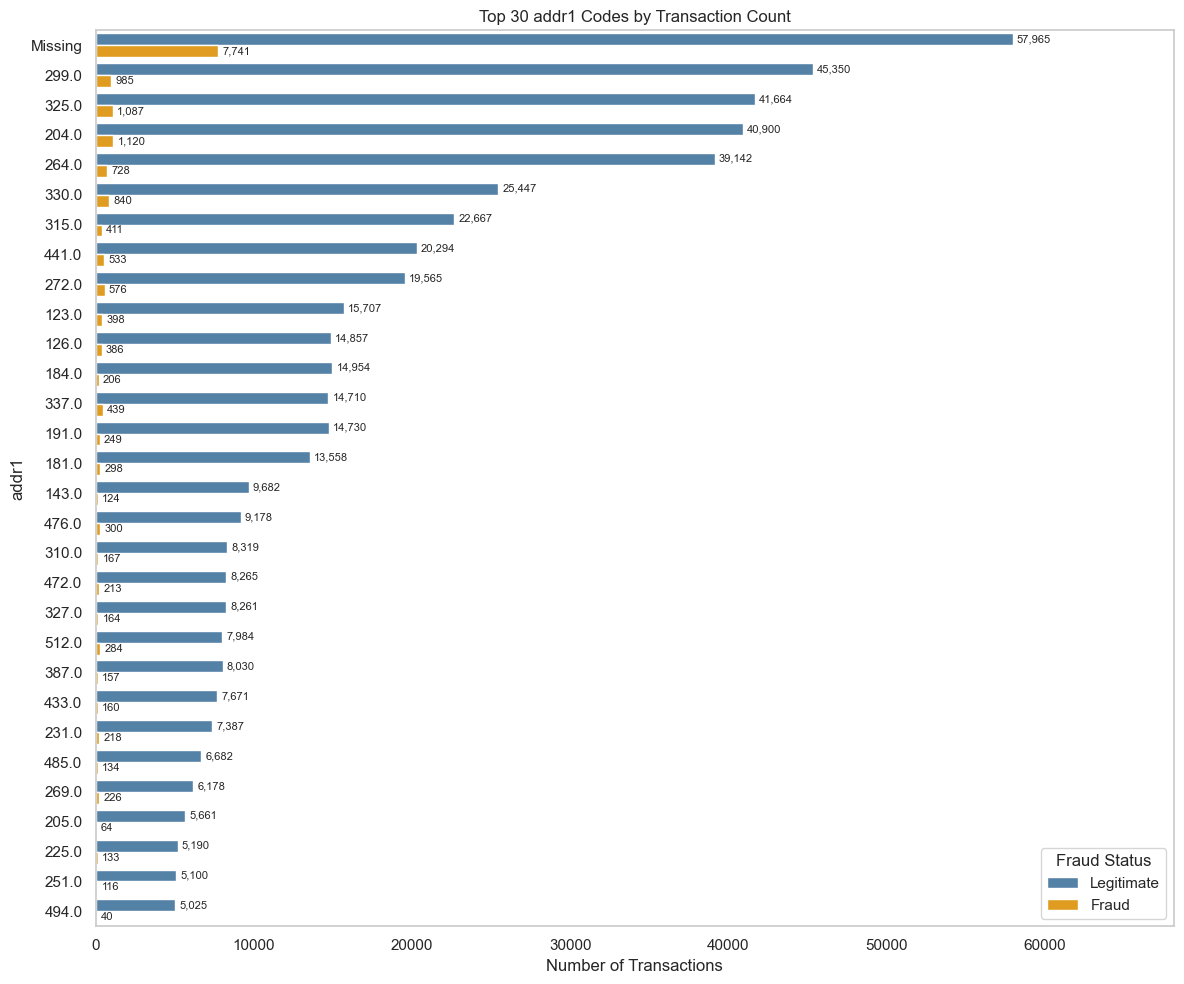

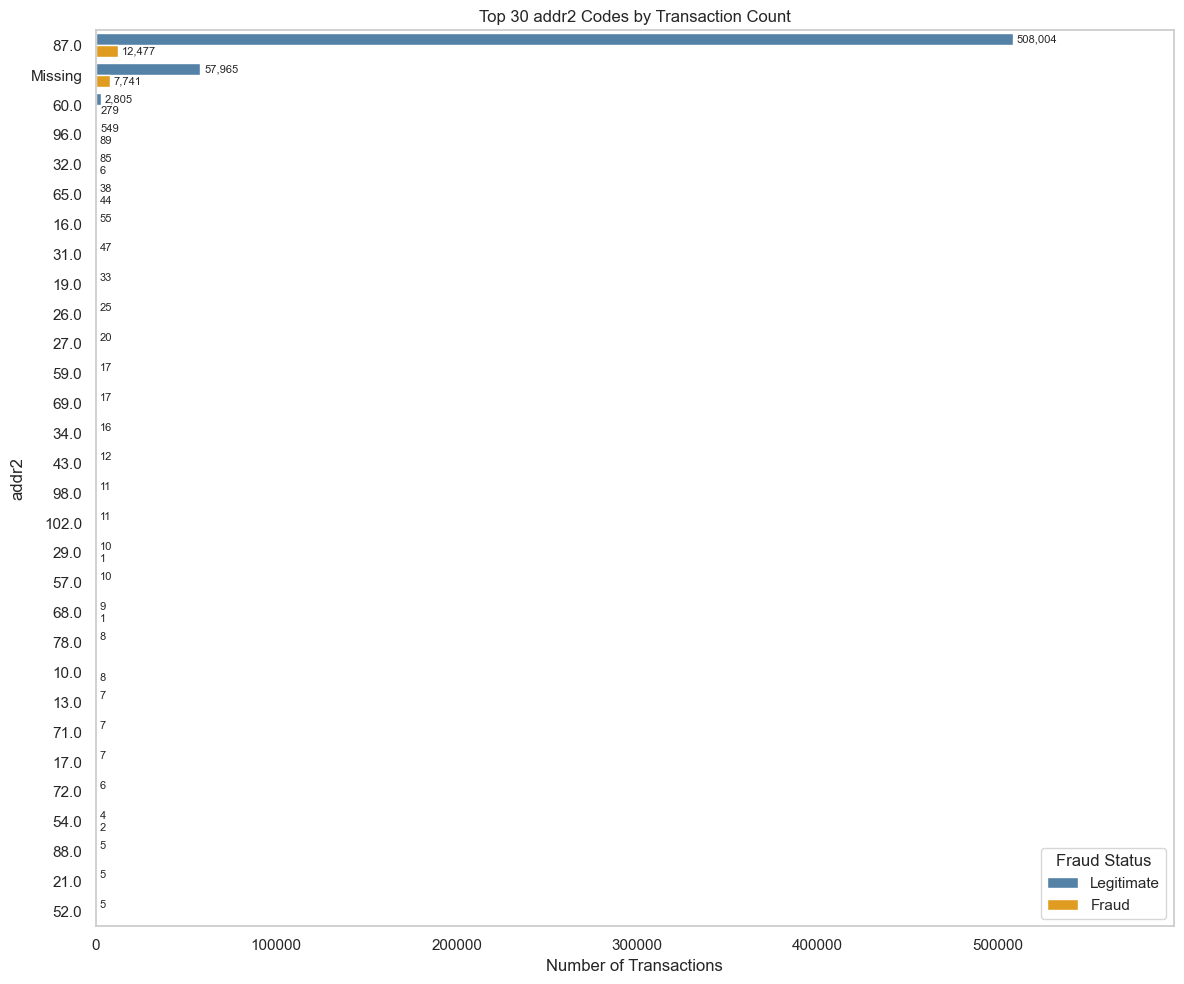

In [55]:
for feature in ["addr1", "addr2"]:

    top_values = df[feature].value_counts().head(30).index
    plot_data = df[df[feature].isin(top_values)]
    colors = { "Legitimate": "steelblue", "Fraud": "orange"}
    plot_data["Fraud Status"] = (plot_data["isFraud"].map({0: "Legitimate", 1: "Fraud"}))
    plt.figure(figsize=(12, 10))
    ax = sns.countplot(data=plot_data, y=feature, hue="Fraud Status", order=top_values, palette=colors)
    # Add transaction numbers to bars
    for container in ax.containers:
        labels = [
            f"{int(value):,}" if value > 0 else ""
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3,fontsize=8)
    ax.set_title(f"Top 30 {feature} Codes by Transaction Count")
    ax.set_xlabel("Number of Transactions")
    ax.set_ylabel(feature)
    ax.grid(False)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.12) # Extra space for labels
    plt.tight_layout()
    plt.show()

The transaction distribution was highly concentrated in a small number of address codes. For addr1, the missing category had the highest number of transactions, followed by codes 299, 325, 204 and 264. Most common addr1 codes had considerably more non-fraudulent than fraudulent transactions. 

For addr2, code 87 strongly dominated the dataset, with approximately 508,004 non-fraudulent and 12,477 fraudulent transactions. Missing addr2 values formed the second-largest category and again showed a higher fraud proportion of approximately 11.78%. Most other addr2 codes contained very few transactions, so their fraud proportions may be unreliable.

These results suggest that address codes and missing address information may help distinguish fraudulent transactions.


## 5.6 M1-M9

### 5.6.1 Checking for null values in M1-M9

In [56]:
m_features = [f"M{i}" for i in range(1, 10)]
df[m_features].isnull().sum()

M1    271100
M2    271100
M3    271100
M4    281444
M5    350482
M6    169360
M7    346265
M8    346252
M9    346252
dtype: int64

### 5.6.2 Filling  null values in M1-M9 with "Missing"

In [57]:
df[m_features] = (df[m_features].astype("string").fillna("Missing"))

In [58]:
df[m_features].isnull().sum()

M1    0
M2    0
M3    0
M4    0
M5    0
M6    0
M7    0
M8    0
M9    0
dtype: int64

### 5.6.3 Display value counts for each M feature

In [59]:
# Display value counts for each M feature
for feature in m_features:
    print( df[feature].value_counts(dropna=False))

M1
T          319415
Missing    271100
F              25
Name: count, dtype: Int64
M2
T          285468
Missing    271100
F           33972
Name: count, dtype: Int64
M3
Missing    271100
T          251731
F           67709
Name: count, dtype: Int64
M4
Missing    281444
M0         196405
M2          59865
M1          52826
Name: count, dtype: Int64
M5
Missing    350482
F          132491
T          107567
Name: count, dtype: Int64
M6
F          227856
T          193324
Missing    169360
Name: count, dtype: Int64
M7
Missing    346265
F          211374
T           32901
Name: count, dtype: Int64
M8
Missing    346252
F          155251
T           89037
Name: count, dtype: Int64
M9
Missing    346252
T          205656
F           38632
Name: count, dtype: Int64


### 5.6.5 Display transaction distribution for each M feature

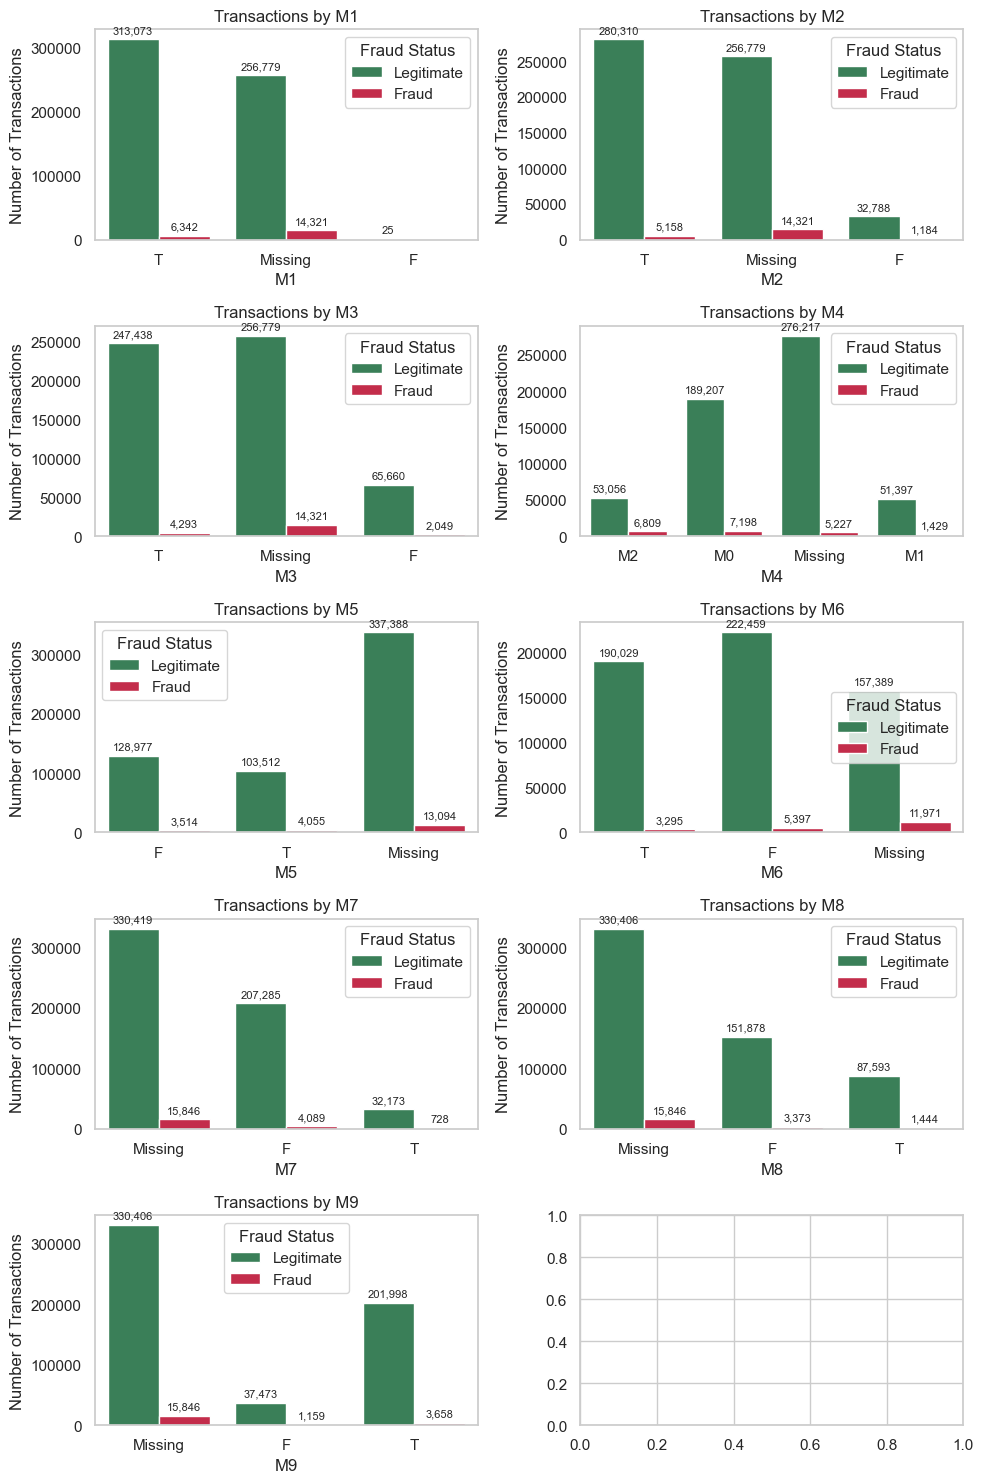

In [60]:
m_features = [f"M{i}" for i in range(1, 10)]
df["Fraud Status"] = (df["isFraud"].map({0: "Legitimate", 1: "Fraud"}))
fig, axes = plt.subplots(5, 2, figsize=(10, 15))
axes = axes.flatten()
colors = {"Legitimate": "seagreen", "Fraud": "crimson"}
for feature, ax in zip(m_features, axes):
    sns.countplot(data=df, x=feature, hue="Fraud Status", palette=colors, ax=ax)
    for container in ax.containers:
        labels = [
            f"{int(value):,}" if value > 0 else ""
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)
    ax.set_title(f"Transactions by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Transactions")
    ax.grid(False)
plt.tight_layout()
plt.show()

### 5.6.6 Display fraud percentage for each M feature

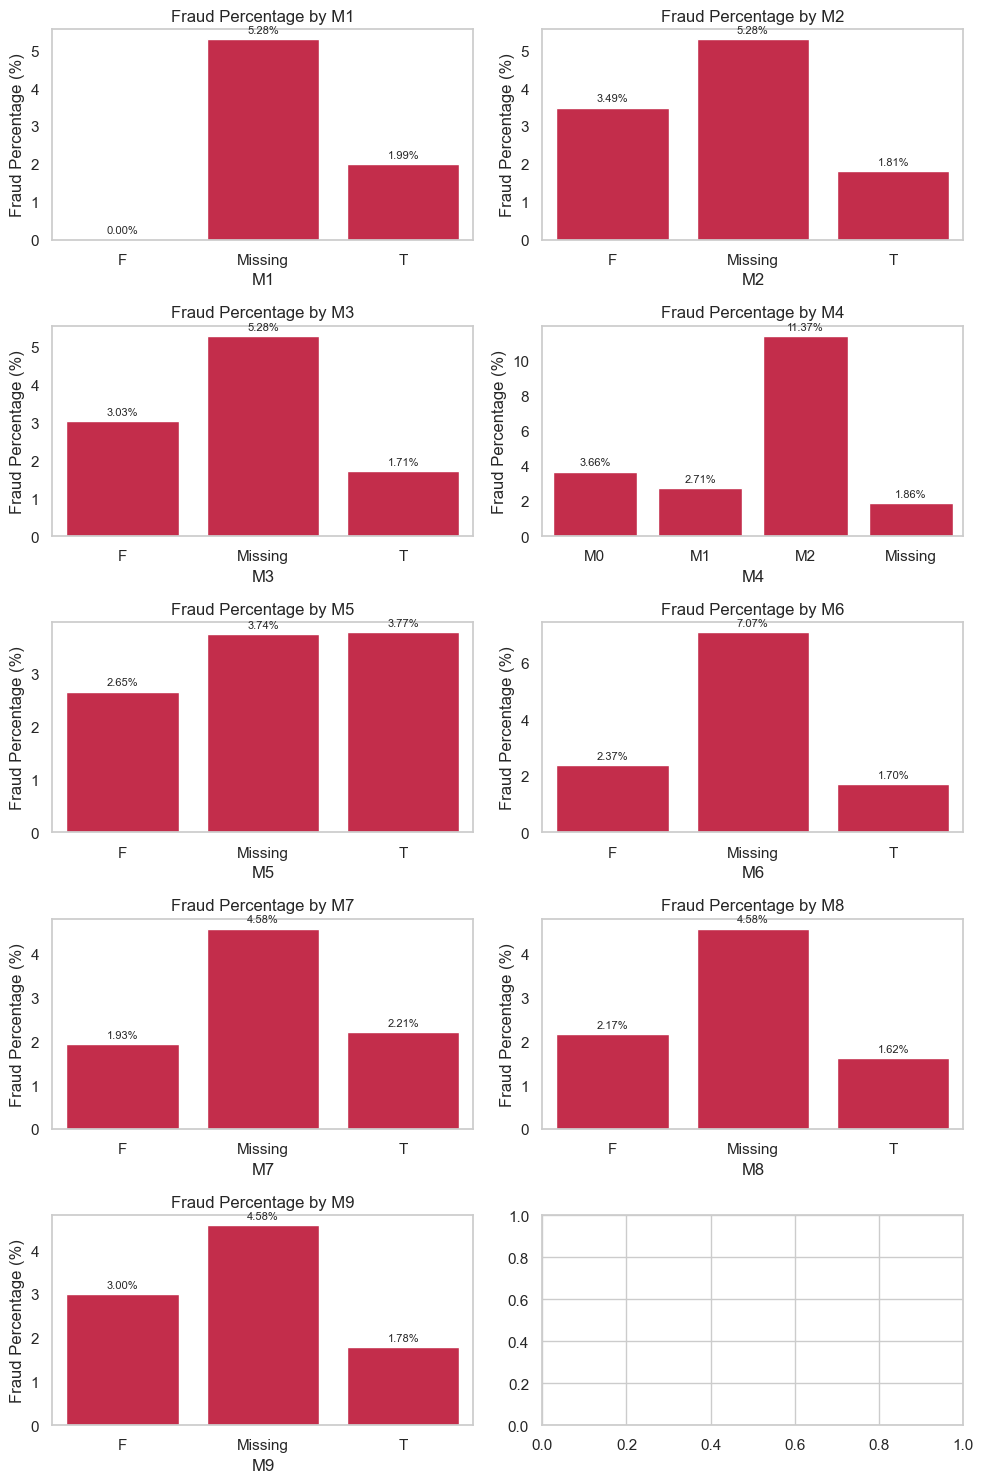

In [61]:
m_features = [f"M{i}" for i in range(1, 10)]

fig, axes = plt.subplots(5, 2, figsize=(10, 15))
axes = axes.flatten()
for feature, ax in zip(m_features, axes):
    fraud_rate = (df.groupby(feature)["isFraud"].mean().mul(100).reset_index(name="Fraud Percentage"))
    sns.barplot(data=fraud_rate, x=feature, y="Fraud Percentage", color="crimson", ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=8)
    ax.set_title(f"Fraud Percentage by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Fraud Percentage (%)")
    ax.grid(False)
plt.tight_layout()
plt.show()

The fraud percentage varied across the matching features M1–M9. The strongest difference was observed in M4, where category M2 had the highest fraud rate at 11.37%. For M6, missing values also showed a relatively high fraud rate of 7.07%.

Missing values had higher fraud percentages in M7, M8 and M9, each at approximately 4.58%, compared with their T and F categories. For M5, the fraud rates for T and missing values were similar, at 3.77% and 3.74%.

Overall, the results suggest that both the matching categories and missing-value patterns may be useful indicators for fraud detection. However, these relationships show association only and do not mean that a particular category directly causes fraud.

## 5.7 DeviceType

### 5.7.1 Check for missing values in Device Type

In [62]:
# Check missing values
print(df["DeviceType"].isnull().sum())

449730


### 5.7.2 Fill missing values in Device Type with "Missing"

In [63]:
# Replace missing values
df["DeviceType"] = (df["DeviceType"].astype("string").fillna("Missing"))

### 5.7.3 Transaction distribution for Device Type

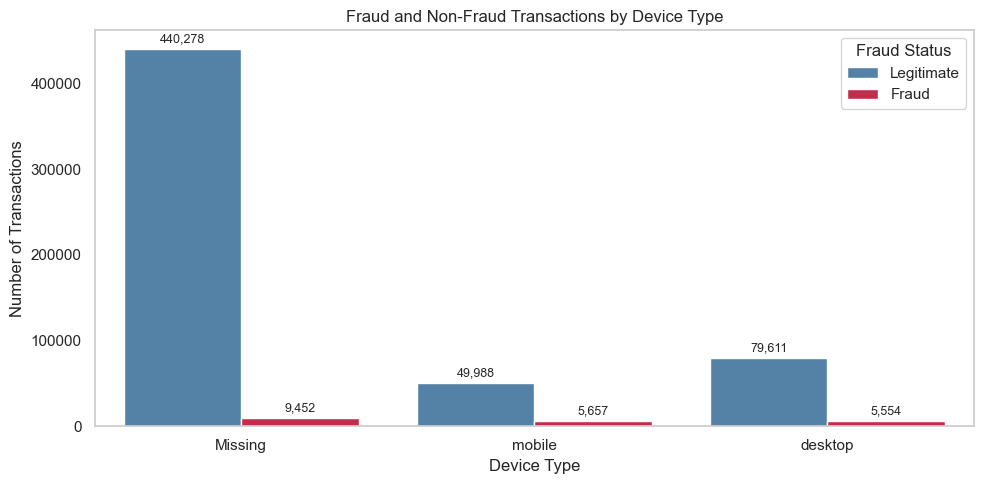

In [64]:
colors = {"Legitimate": "steelblue", "Fraud": "crimson"}
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="DeviceType", hue="Fraud Status", palette=colors)
for container in ax.containers: 
    labels = [
        f"{int(value):,}" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)
ax.set_title("Fraud and Non-Fraud Transactions by Device Type")
ax.set_xlabel("Device Type")
ax.set_ylabel("Number of Transactions")
ax.grid(False)
plt.tight_layout()
plt.show()

The DeviceType distribution was dominated by missing values, with 440,278 non-fraudulent and 9,452 fraudulent transactions. 

 ## 5.8  DeviceInfo

### 5.8.1 Check for missing values in Device Info

In [65]:
# Check missing values
print(df["DeviceInfo"].isnull().sum())

471874


### 5.8.2 Fill missing values in DeviceInfo with "Missing"

In [66]:
# Replace missing DeviceInfo values
df["DeviceInfo"] = (df["DeviceInfo"].astype("string").fillna("Missing"))

In [67]:
print(df["DeviceInfo"].isnull().sum())

0


### 5.8.3 10 most common device-information categories

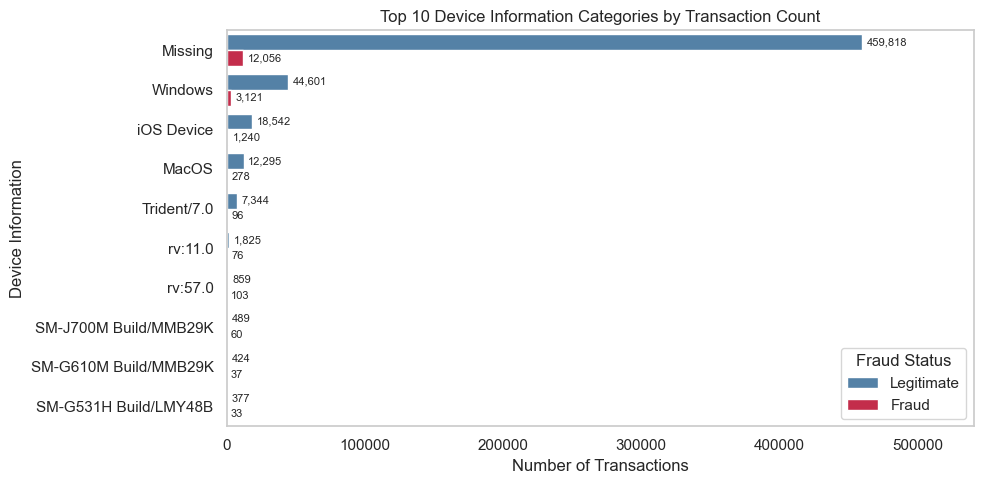

In [68]:
# Select the 10 most common device-information categories
top_values = df["DeviceInfo"].value_counts().head(10).index
plot_data = df[df["DeviceInfo"].isin(top_values)]

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=plot_data, y="DeviceInfo", hue="Fraud Status", order=top_values, palette=colors)
for container in ax.containers: 
    labels = [
        f"{int(value):,}" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)
ax.set_title("Top 10 Device Information Categories by Transaction Count")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Device Information")
ax.grid(False)
ax.set_xlim(right=ax.get_xlim()[1] * 1.12)
plt.tight_layout()
plt.show()

The DeviceInfo feature was dominated by missing values, with 459,818 non-fraudulent and 12,056 fraudulent transactions. Windows had the highest number of transactions, followed by iOS Device and MacOS. Fraudulent transactions were much fewer than non-fraudulent transactions in every category. Some less common device categories showed a higher fraud proportion, but they contained very few transactions, so these rates may not be reliable. Overall, DeviceInfo may provide useful information for fraud detection, although its large number of missing values and many rare categories limit its interpretation.

## 5.9 Id 12- 38

### 5.9.1 Check for missing values in Id12-Id38

In [69]:
id_features = [f"id_{i:02d}" for i in range(12, 39)]
id_missing = pd.DataFrame({
    "Missing Count": df[id_features].isnull().sum(),
    "Missing Percentage": (
        df[id_features].isnull().mean() * 100
    ).round(2)
})

display(id_missing)

,Missing Count,Missing Percentage
id_12,446307,75.58
id_13,463220,78.44
id_14,510496,86.45
id_15,449555,76.13
id_16,461200,78.10
id_17,451171,76.40
id_18,545427,92.36
id_19,451222,76.41
id_20,451279,76.42
id_21,585381,99.13


The categorical identity features id_12 to id_38 contained very high levels of missing data. All features had more than 75% missing values. The highest missingness was found in id_21 to id_27, where approximately 99% of values were missing. id_18 also had 92.36% missing values, while id_14, id_30, id_32, id_33 and id_34 had around 86%–88% missingness. The remaining features generally had missing percentages between 75% and 78%. This confirms that many identity-related features were sparsely bserved, partly because identity-table records were available for only a subset of transactions.

# 6 Corelation analysis

## 6.1 Correlation using Cramér's V for categorical features 

In [70]:
# Categorical Association Analysis using Cramér's V
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    if table.empty:
        return 0

    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    if n <= 1:
        return 0

    r, k = table.shape
    phi2 = chi2 / n

    # Bias correction
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))

    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(r_corrected - 1, k_corrected - 1)
    if denominator <= 0:
        return 0
    
    return np.sqrt(phi2_corrected / denominator)

In [71]:
# Prepare categorical data
categorical_df = df[categorical_features].copy()

# Treat missing values as a separate category
for col in categorical_features:
    categorical_df[col] = (
        categorical_df[col]
        .astype("string")
        .fillna("MISSING")
    )

In [72]:
# Calculate Cramér's V matrix
cramers_matrix = pd.DataFrame(np.eye(len(categorical_features)), index=categorical_features, columns=categorical_features)

for i in range(len(categorical_features)):
    for j in range(i + 1, len(categorical_features)):
        
        col1 = categorical_features[i]
        col2 = categorical_features[j]

        value = cramers_v(
            categorical_df[col1],
            categorical_df[col2]
        )

        cramers_matrix.loc[col1, col2] = value
        cramers_matrix.loc[col2, col1] = value

display(cramers_matrix.round(3))

,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9,DeviceType,DeviceInfo,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
ProductCD,1.000,0.628,0.538,0.484,0.182,0.392,0.193,0.531,0.501,0.322,0.562,0.450,0.450,0.450,0.548,0.343,0.653,0.348,0.348,0.348,0.688,0.549,0.762,0.517,0.498,0.575,0.652,0.665,0.272,0.689,0.719,0.134,0.117,0.126,0.111,0.134,0.136,0.151,0.685,0.685,0.520,0.543,0.490,0.496,0.492,0.945,0.689,0.689,0.822
card1,0.628,1.000,0.980,0.974,0.858,0.934,0.704,0.369,0.739,0.332,0.322,0.344,0.353,0.358,0.543,0.365,0.546,0.333,0.308,0.290,0.536,0.222,0.591,0.192,0.505,0.459,0.478,0.638,0.257,0.294,0.514,0.216,0.422,0.251,0.330,0.252,0.316,0.176,0.521,0.521,0.205,0.203,0.460,0.187,0.315,0.738,0.518,0.528,0.552
card2,0.538,0.980,1.000,0.267,0.809,0.270,0.468,0.150,0.141,0.135,0.152,0.311,0.313,0.311,0.483,0.263,0.467,0.254,0.247,0.246,0.457,0.078,0.498,0.106,0.123,0.380,0.402,0.145,0.087,0.074,0.096,0.021,0.051,0.078,0.047,0.026,0.043,0.084,0.448,0.448,0.066,0.077,0.228,0.038,0.226,0.675,0.443,0.450,0.482
card3,0.484,0.974,0.267,1.000,0.500,0.144,0.508,0.161,0.463,0.135,0.157,0.273,0.273,0.273,0.480,0.208,0.396,0.211,0.211,0.211,0.396,0.217,0.432,0.096,0.286,0.339,0.326,0.422,0.076,0.166,0.418,0.044,0.178,0.039,0.193,0.090,0.081,0.021,0.390,0.389,0.026,0.077,0.071,0.045,0.071,0.629,0.387,0.395,0.424
card4,0.182,0.858,0.809,0.500,1.000,0.733,0.515,0.091,0.041,0.072,0.142,0.094,0.094,0.094,0.082,0.071,0.136,0.076,0.074,0.074,0.156,0.144,0.164,0.112,0.147,0.124,0.151,0.153,0.072,0.172,0.164,0.044,0.022,0.025,0.021,0.044,0.030,0.032,0.148,0.148,0.156,0.126,0.151,0.155,0.149,0.212,0.147,0.148,0.149
card5,0.392,0.934,0.270,0.144,0.733,1.000,0.439,0.102,0.106,0.068,0.097,0.228,0.229,0.229,0.330,0.178,0.354,0.181,0.180,0.180,0.345,0.122,0.368,0.075,0.095,0.281,0.306,0.110,0.066,0.124,0.155,0.040,0.063,0.053,0.024,0.044,0.042,0.060,0.336,0.336,0.051,0.058,0.188,0.045,0.185,0.486,0.331,0.336,0.353
card6,0.193,0.704,0.468,0.508,0.515,0.439,1.000,0.179,0.077,0.114,0.184,0.167,0.167,0.167,0.089,0.111,0.248,0.126,0.125,0.125,0.251,0.175,0.251,0.168,0.163,0.201,0.237,0.184,0.089,0.204,0.191,0.021,0.028,0.033,0.026,0.026,0.030,0.039,0.246,0.246,0.166,0.181,0.164,0.160,0.163,0.258,0.244,0.244,0.244
addr1,0.531,0.369,0.150,0.161,0.091,0.102,0.179,1.000,0.546,0.101,0.114,0.320,0.289,0.288,0.510,0.265,0.423,0.237,0.240,0.234,0.423,0.070,0.467,0.173,0.331,0.356,0.351,0.183,0.088,0.102,0.245,0.000,0.025,0.026,0.019,0.000,0.030,0.023,0.415,0.415,0.029,0.075,0.116,0.026,0.118,0.664,0.412,0.416,0.465
addr2,0.501,0.739,0.141,0.463,0.041,0.106,0.077,0.546,1.000,0.068,0.102,0.283,0.280,0.280,0.495,0.214,0.408,0.217,0.217,0.217,0.408,0.181,0.445,0.094,0.367,0.343,0.333,0.432,0.071,0.169,0.498,0.067,0.245,0.044,0.251,0.154,0.127,0.026,0.401,0.400,0.041,0.086,0.080,0.086,0.087,0.650,0.399,0.402,0.449
P_emaildomain,0.322,0.332,0.135,0.135,0.072,0.068,0.114,0.101,0.068,1.000,0.556,0.163,0.164,0.165,0.260,0.131,0.256,0.133,0.127,0.126,0.250,0.168,0.269,0.056,0.050,0.203,0.210,0.079,0.052,0.106,0.134,0.016,0.011,0.028,0.020,0.027,0.010,0.028,0.240,0.239,0.036,0.083,0.104,0.039,0.101,0.337,0.235,0.241,0.251


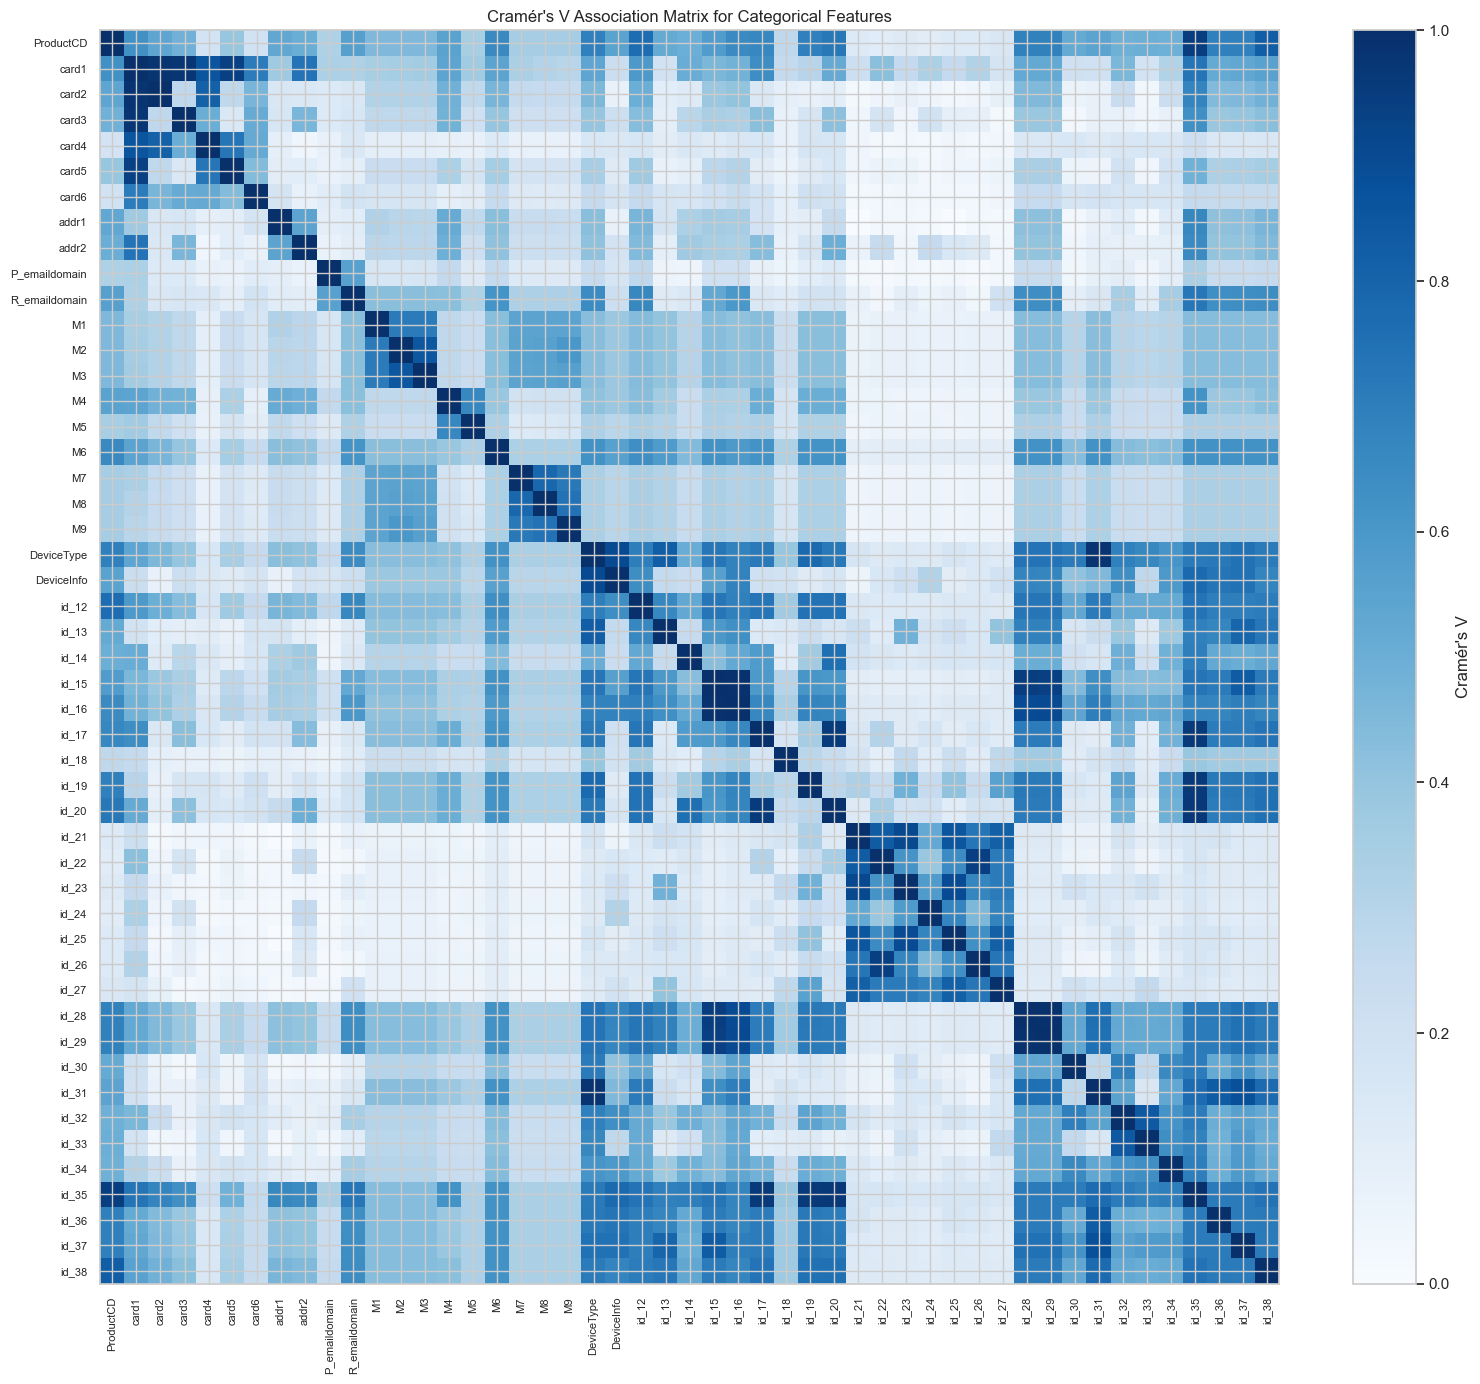

In [73]:
# Heatmap of Cramér's V matrix
plt.figure(figsize=(16, 14))
plt.imshow(cramers_matrix, aspect="auto", vmin=0, vmax=1, cmap="Blues")
plt.colorbar(label="Cramér's V")
plt.xticks(range(len(cramers_matrix.columns)), cramers_matrix.columns, rotation=90, fontsize=8)
plt.yticks(range(len(cramers_matrix.index)), cramers_matrix.index, fontsize=8)
plt.title("Cramér's V Association Matrix for Categorical Features")
plt.tight_layout()
plt.show()

In [74]:
# Identify highly associated categorical pairs
cramers_threshold = 0.95
high_cramers_pairs = []
for i in range(len(categorical_features)):
    for j in range(i + 1, len(categorical_features)):

        value = cramers_matrix.iloc[i, j]
        if value > cramers_threshold:
            high_cramers_pairs.append(
                (
                    categorical_features[i],
                    categorical_features[j],
                    value
                )
            )

high_cramers_pairs = sorted(high_cramers_pairs, key=lambda x: x[2], reverse=True)
print("Number of highly associated categorical pairs:", len(high_cramers_pairs))
for col1, col2, value in high_cramers_pairs:
    print(f"{col1} - {col2}: {value:.4f}")

Number of highly associated categorical pairs: 9
id_28 - id_29: 0.9908
id_15 - id_16: 0.9893
DeviceType - id_31: 0.9827
card1 - card2: 0.9800
card1 - card3: 0.9740
id_20 - id_35: 0.9665
id_17 - id_35: 0.9648
id_19 - id_35: 0.9636
id_17 - id_20: 0.9547


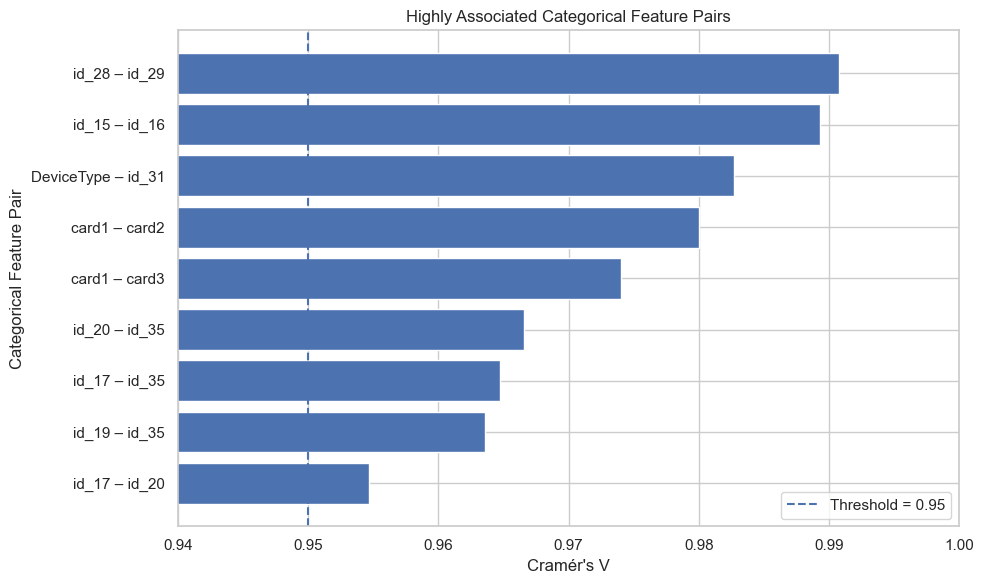

In [75]:
# Plot highly associated categorical pairs
cramers_pairs_df = pd.DataFrame(high_cramers_pairs, columns=["Feature 1", "Feature 2", "Cramers_V"])
cramers_pairs_df = cramers_pairs_df.sort_values("Cramers_V", ascending=True)
if not cramers_pairs_df.empty:

    cramers_pairs_df["Pair"] = (cramers_pairs_df["Feature 1"] + " – " + cramers_pairs_df["Feature 2"])

    cramers_pairs_df = cramers_pairs_df.sort_values("Cramers_V")
    plt.figure(figsize=(10, 6))
    plt.barh(cramers_pairs_df["Pair"], cramers_pairs_df["Cramers_V"])
    plt.axvline(x=cramers_threshold, linestyle="--", label="Threshold = 0.95")
    plt.xlabel("Cramér's V")
    plt.ylabel("Categorical Feature Pair")
    plt.title("Highly Associated Categorical Feature Pairs")
    plt.xlim(0.94, 1.00)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("No categorical pairs exceeded the threshold.")

Cramér’s V was used to examine the strength of association of categorical variables. Several associated pairs were identified, especially among identity-related variables and card-related features. The strongest associations included id_28–id_29, id_15–id_16, DeviceType–id_31, and card1–card2. These results indicate that some categorical variables contain related information.

## 6.2 Correlation using Pearson coefficient for numerical features

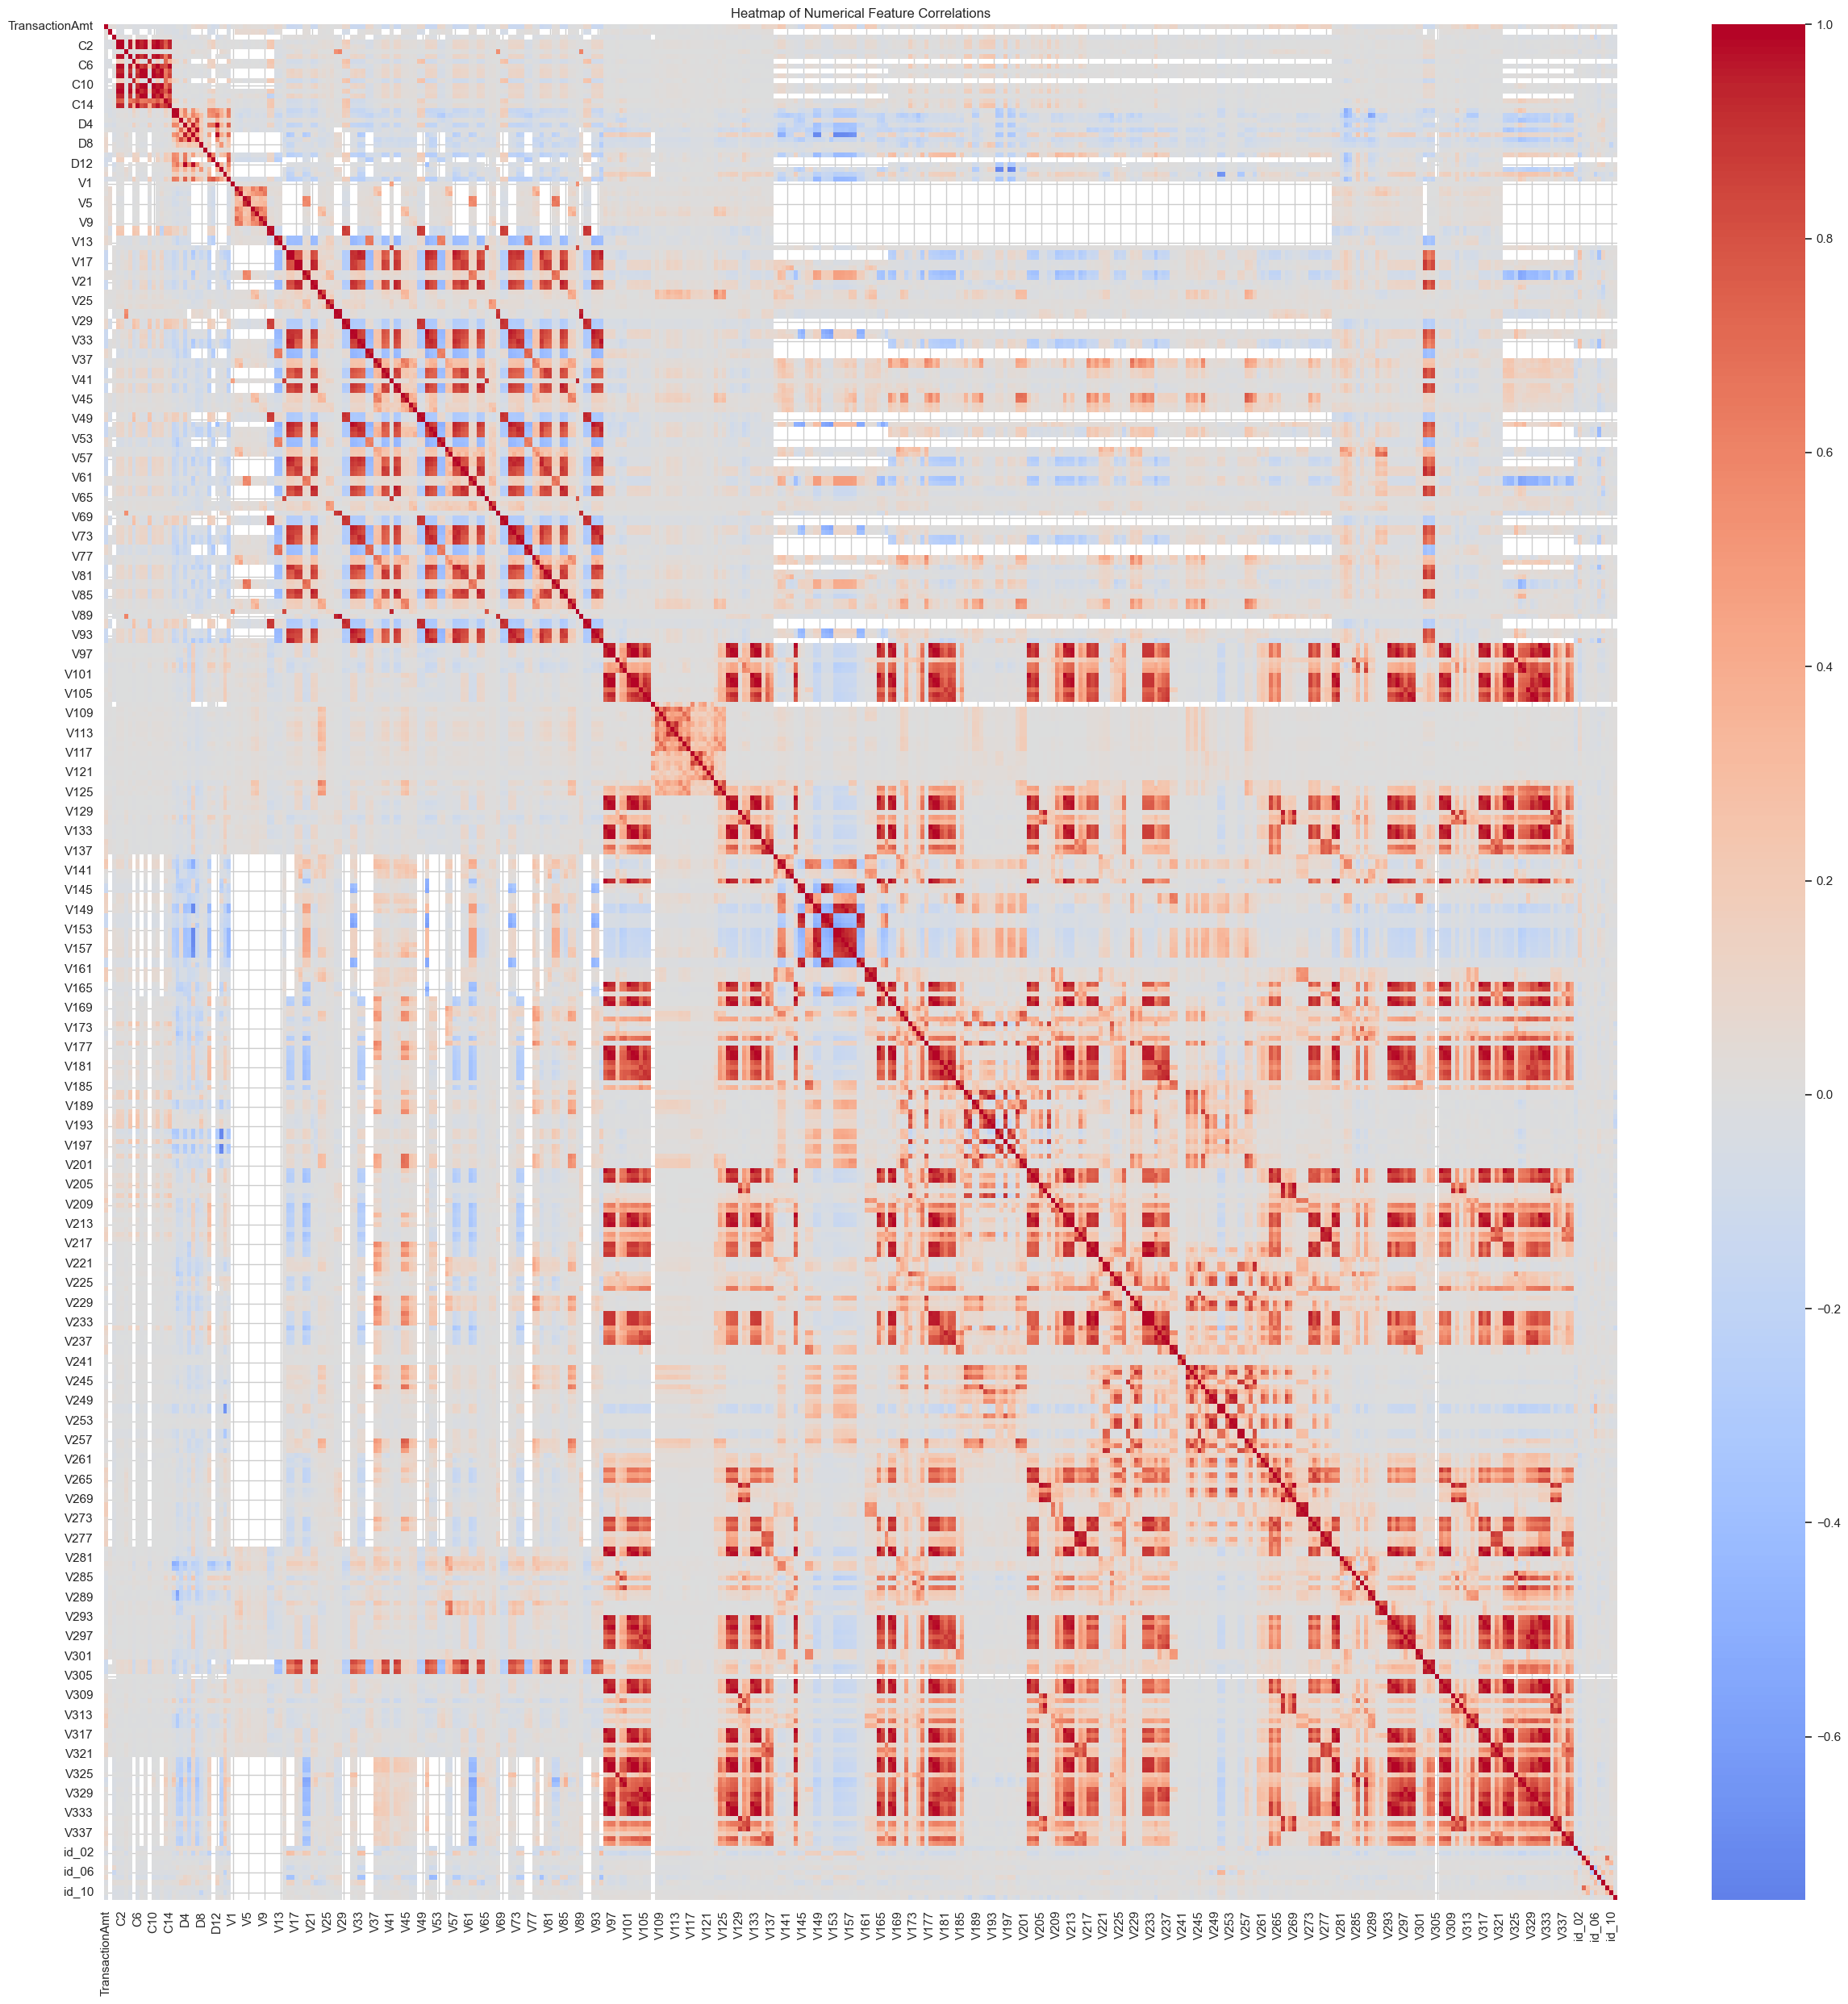

In [76]:
correlation_df = df.copy()
categorical_features = (["ProductCD"]+ [f"card{i}" for i in range(1, 7)] + ["addr1", "addr2", "P_emaildomain", "R_emaildomain"] + [f"M{i}" for i in range(1, 10)] + ["DeviceType", "DeviceInfo"]+ [f"id_{i:02d}" for i in range(12, 39)])
other_columns_to_drop = ["isFraud", "has_identity", "TransactionID", "TransactionDT", "TransactionDay", "TransactionWeek", "RelativeWeekday", "RelativeHour", "Fraud Status"]
correlation_df.drop(columns=categorical_features + other_columns_to_drop, errors="ignore", inplace=True)
correlation_matrix = correlation_df.corr(numeric_only=True)

plt.figure(figsize=(25, 25))
sns.heatmap(correlation_matrix, cmap="coolwarm",center=0)
plt.title("Heatmap of Numerical Feature Correlations")
plt.tight_layout()
plt.show()

Top 30 strongly correlated numerical feature pairs

Number of features shown in heatmap: 29


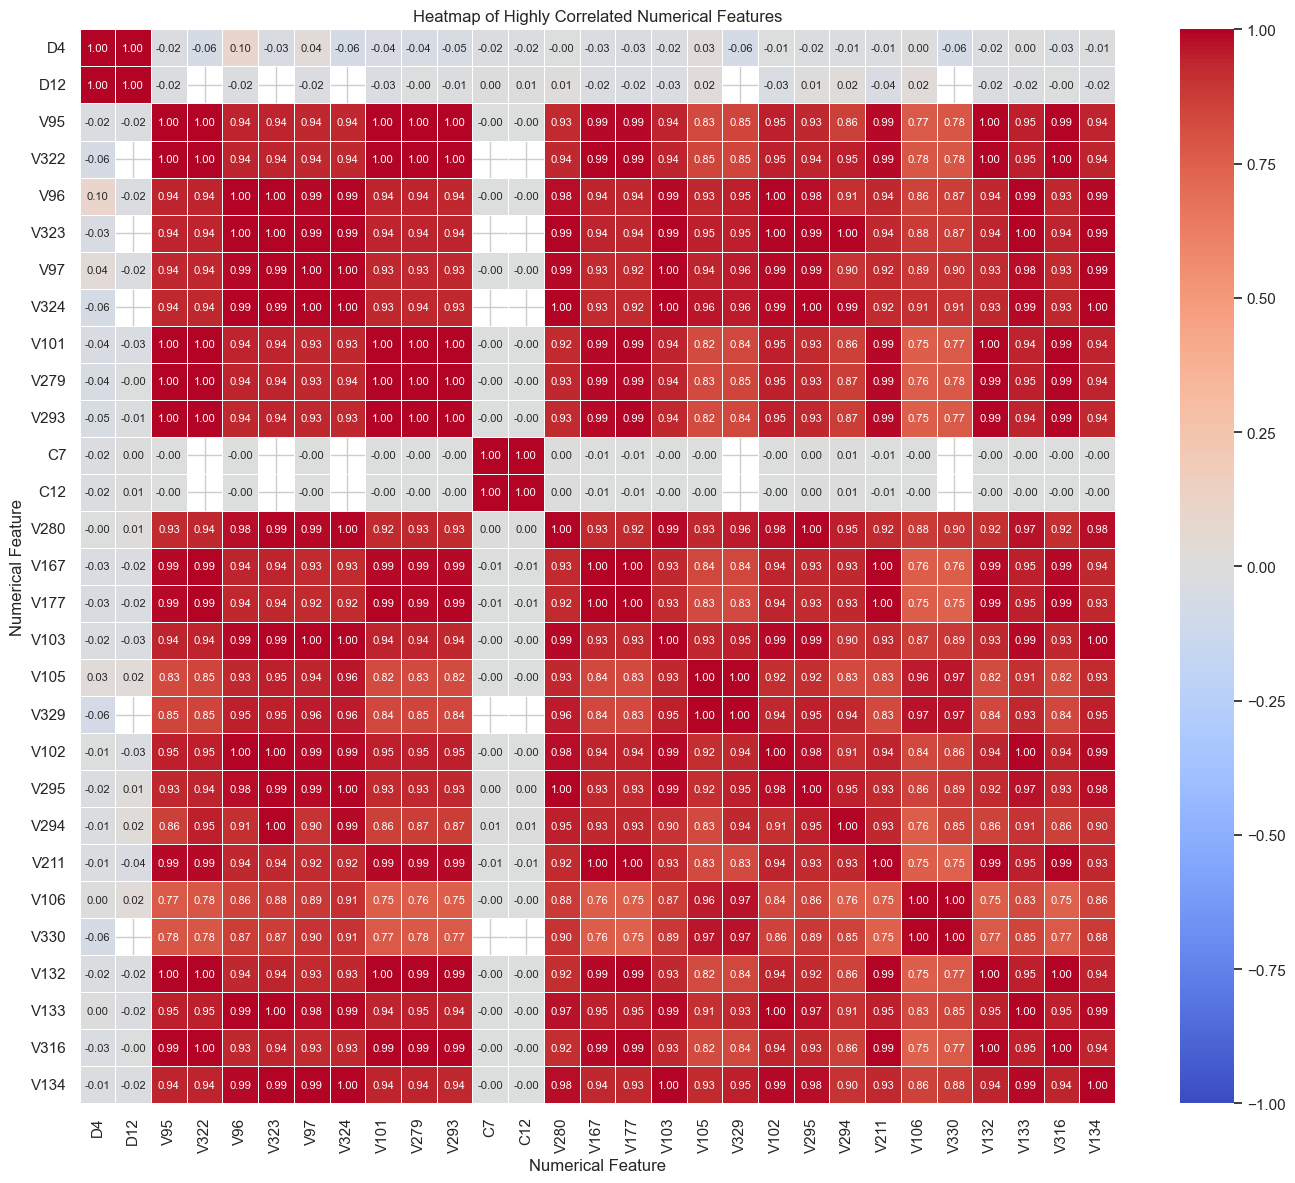

In [77]:
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlation_pairs = (upper_triangle.stack().reset_index())
correlation_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# Use absolute correlation to find strongest relationships
correlation_pairs["Absolute Correlation"] = (correlation_pairs["Correlation"].abs())

# Sort from strongest to weakest
correlation_pairs = correlation_pairs.sort_values("Absolute Correlation", ascending=False)

# Plot the features involved in the top 30 strongest pairs
top_correlation_pairs = correlation_pairs.head(30)
selected_features = pd.unique(top_correlation_pairs[["Feature 1", "Feature 2"]].values.ravel())
print("Number of features shown in heatmap:", len(selected_features))

top_features_correlation_matrix = (correlation_matrix.loc[selected_features, selected_features])
plt.figure(figsize=(14, 12))
sns.heatmap(top_features_correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5)
plt.title("Heatmap of Highly Correlated Numerical Features")
plt.xlabel("Numerical Feature")
plt.ylabel("Numerical Feature")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The correlation heatmap shows several groups of strongly correlated numerical variables. The clearest correlation patterns occur among the anonymised V features, where multiple red blocks indicate strong positive relationships and some blue areas indicate negative relationships. Several C and D variables also show moderate to strong correlations within their feature groups. This suggests that some numerical features may contain overlapping or redundant information. Most relationships outside these clusters are weak and close to zero. The white areas represent correlations that could not be calculated, mainly because of extensive missing values or insufficient variation in some columns. Since isFraud was excluded, the heatmap represents correlations between predictor variables only.

In [78]:
# Add the target column
pearson_df = correlation_df.copy()
pearson_df["isFraud"] = df["isFraud"]

# Calculate Pearson correlation coefficients with isFraud
pearson_coefficients = (pearson_df.corr(method="pearson", numeric_only=True)["isFraud"].drop("isFraud").sort_values())
display(pearson_coefficients.rename("Pearson Correlation").to_frame())

,Pearson Correlation
D8,-0.142636
D7,-0.127199
id_01,-0.120099
V48,-0.115786
V49,-0.110920
...,...
V201,0.328005
V242,0.360590
V244,0.364129
V246,0.366878


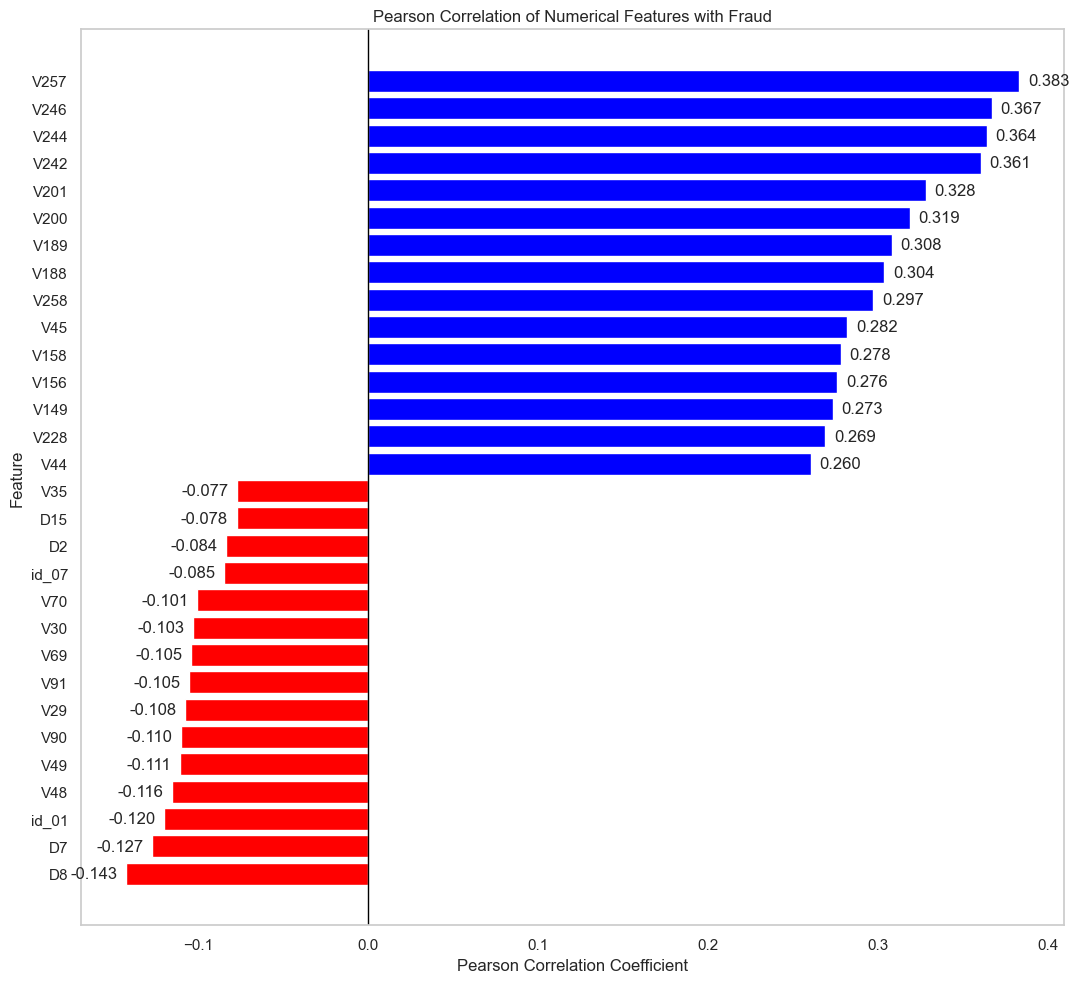

In [79]:
top_positive = pearson_coefficients.nlargest(15)
top_negative = pearson_coefficients.nsmallest(15)
combined_pearson = pd.concat([top_negative, top_positive]).sort_values()
colors = ["red" if value < 0 else "blue" for value in combined_pearson.values]

plt.figure(figsize=(11, 10))
bars = plt.barh(combined_pearson.index, combined_pearson.values, color=colors)
for bar, value in zip(bars, combined_pearson.values):
    x_position = value + 0.005 if value >= 0 else value - 0.005
    alignment = "left" if value >= 0 else "right"

    plt.text(x_position, bar.get_y() + bar.get_height() / 2,f"{value:.3f}", ha=alignment, va="center")
plt.axvline(0, color="black", linewidth=1)
plt.title("Pearson Correlation of Numerical Features with Fraud")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Feature")
plt.grid(False)
plt.tight_layout()
plt.show()

Pearson correlation was used to examine linear associations between numerical features and the fraud target.

The strongest positive linear association was observed for V257 (r = 0.383), followed by V246 (r = 0.367), V244 (r = 0.364) and V242 (r = 0.361). Higher values of these features were therefore associated with the fraudulent class, although correlation does not imply causation.

The strongest negative associations were observed for D8 (r = -0.143), D7 (r = -0.127) and id_01 (r = -0.120). These associations were weaker in magnitude than the strongest positive correlations.

No numerical feature had an absolute Pearson correlation above 0.40, indicating that no individual numerical feature showed a particularly strong linear relationship with fraud. However, low Pearson correlation does not imply that a feature lacks predictive value because non-linear models may capture more complex relationships and feature interactions.

Because many numerical variables contained missing values, pairwise correlations were calculated using available observations. These coefficients should therefore be interpreted as exploratory associations rather than final measures of feature importance.

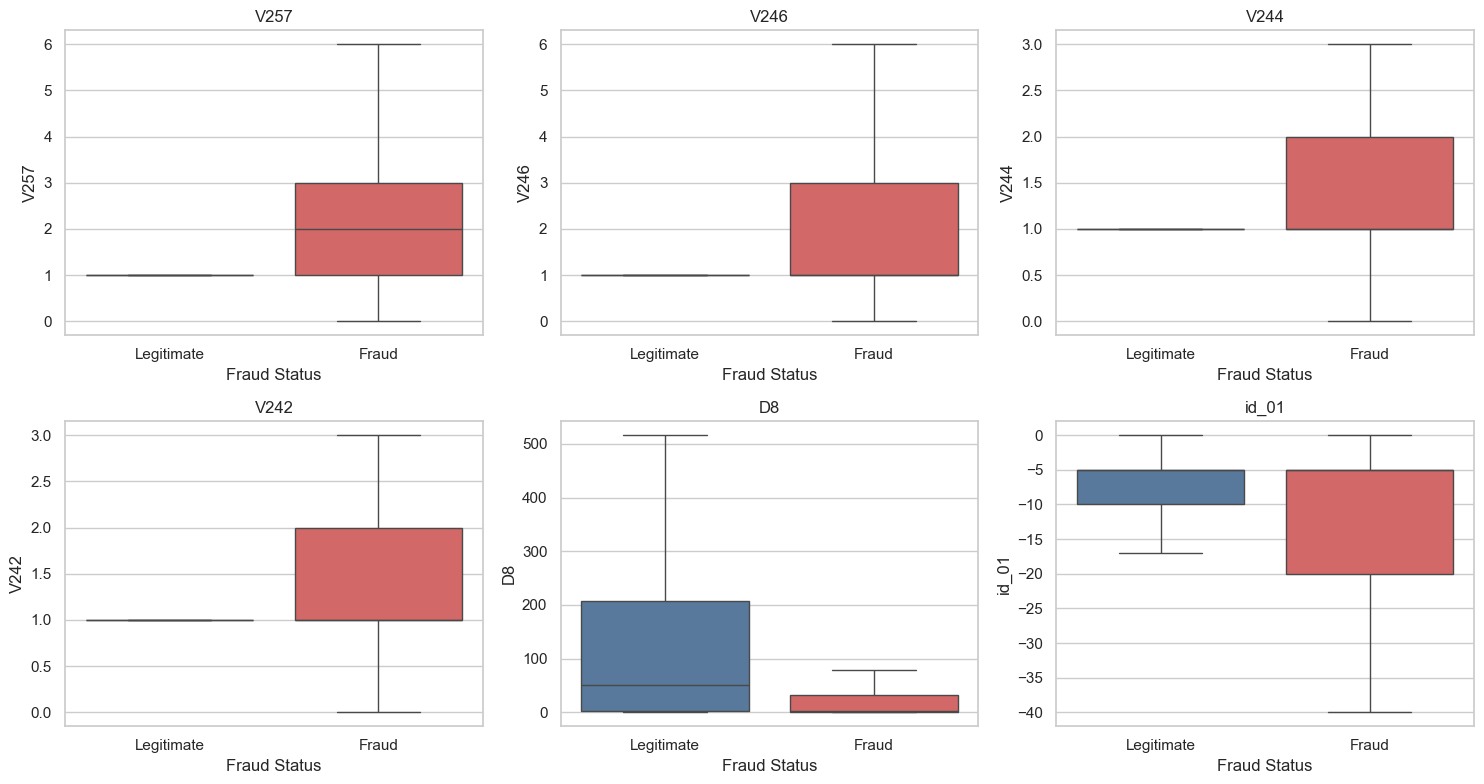

In [80]:
# Top features based on Pearson correlation with isFraud
top_features = ["V257", "V246", "V244", "V242", "D8", "id_01"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for feature, ax in zip(top_features, axes):
    plot_data = df[[feature, "isFraud"]].dropna()

    sns.boxplot(data=plot_data, x="isFraud", y=feature, showfliers=False, ax=ax, palette={"0": "#4C78A8", "1" : "#E45756" })
    ax.set_title(feature)
    ax.set_xlabel("Fraud Status")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

# 7. EDA Summary



The exploratory analysis identified several important characteristics of the IEEE-CIS fraud dataset. The Key Findings:


• Severe Class Imbalance: Out of 590,540 transactions, only 20,663(3.50%) were fraudulent which shows class imbalance. This suggested that accuracy alone would not be sufficient as an evaluation metric.


• Missingness: The dataset had high missingness. Out of 435 merged columns, 414 columns contained missing values. Many identity-related features had high missingness (exceeding 70-90%), also, the transaction features were incomplete.

• Fraud rate with identity data: There were 446,307 transactions with identity records and 144,233 without. Transactions which had identity data had a fraud rate of 7.85%, whereas those with no identity data had 2.09%. 
The identity table was only a subset of the transaction table. So, the higher rate might reflect that the identity data was collected only for certain types of transactions. 


• Extreme Transaction Amount: The transaction amount was heavily right-skewed. 11.26%, which consisted of 66,482 transactions, had very high values, above the upper threshold of 247.52. So, the transaction amount was transformed using log1p(TransactionAmt).


• Temporal Variation in Fraud rate: The fraud rate varied over time. For the full observation period, the fraud rate varies from approximately 1-7%, whereas the weekly fraud rate varied from 1.8% to 5%. Across the derived 7-day cycle, it varies between 3.15% and 3.72%, and for 24-hours cycle, it varies from 2% to 11%. These results suggested that the fraud rate was not constant over time. TransactionDt represented elapsed time from a reference point which was not disclosed; hence, these are referred to as temporal cycles, not actual weekdays or clock hours.


• Fraud Rate over categories: Fraud rate also varied across categories like product, card, email, matching and device/identity related variables.


• Redundant variables: Cramer's V identified that nine categorical pairs were above 0.95, including id_28–id_29 (0.9908), id_15–id_16 (0.9893), DeviceType–id_31 (0.9827), and card1–card2 (0.9800). Numerical features also showed groups of strong mutual correlations (within V-Features, and some C- and D- features). The individual linear association with fraud was maximum 0.38(Pearson correlation). These associations were checked for insight only, not to drop the variables.
